# Lighter vault-of-vaults release candidate — overspent fix

Based on: `scratchpad/hyperliquid-waterfall-rc/17-backtest-overspent-fix.ipynb`, re-pointed from the
Hyperliquid (Hypercore) vault universe to the Lighter (ZK-rollup perps DEX) public-pool universe.

## Hypothesis

This variant keeps the reference strategy unchanged — a positive trailing-180-day-Sharpe gate, a
0.875-year age-ramp, a 20-vault basket, a 20% portfolio concentration cap, a 20% pool-TVL cap, a
0.125-year age gate, and 100,000 USD initial capital. It enables the synchronous-cash cap when
generating rebalance trades, scaling reserve-spending buys to current cash plus only the sells that
execute in the same cycle. A 50 USD headroom accounts for fees, price impact, and rounding. The goal is
to check whether the same reserve-reconciliation discipline that fixed Hyperliquid overspending holds on
the Lighter pool universe.

## Universe notes

- Lighter pools are non-EVM: the off-chain metrics pipeline publishes them under the synthetic chain id
  `9998` with synthetic addresses of the form `lighter-pool-{account_index}` and a placeholder zero
  denomination-token address. All Lighter pools are USDC-denominated.
- The Lighter cohort is young: the bulk of pools launched from August 2025 onward, so the effective
  backtest ramps up over autumn 2025 as pools clear the 0.125-year age gate. Only ~7 candidate signals
  survive the gate in a typical cycle (mean 7.2), against 18 at the end of the window.
- Every Lighter pool currently carries a `Severe` risk label in the metrics feed; the curator's
  `Blacklisted`/`Dangerous` exclusion does not remove them, so this is an exploratory universe rather
  than a production-grade allowlist.

## Key new insights and what we learnt from this experiment

- The synchronous-cash cap completes the full backtest without an `OutOfSimulatedBalance` exception on
  the Lighter universe, making 1,985 trades across 99 vault positions.
- Reserve reconciliation holds, but capacity is the binding constraint: mean accepted deployment is only
  80.39% of investable equity and mean cash sits at 21.51%, because the young/thin Lighter cohort leaves
  ~1.85 signals per cycle pool-size capped and ~1.1 too small to trade. Only 72.3% of cycles clear 75%
  deployment (Hyperliquid cleared 75% every cycle).
- On the currently fetched 34-pool Lighter universe the strategy finishes at 120,595.40 USD: 20.60%
  cumulative return, 22.12% CAGR, 0.70 Sharpe, and a deep -26.65% maximum drawdown. Risk-adjusted
  performance is far weaker than the Hyperliquid release candidate (2.68 Sharpe, -8.56% drawdown) — the
  same strategy on a younger, higher-risk pool set is positive but materially more volatile.

## Summary of results

| Metric | Result |
| --- | ---: |
| Initial / final equity | 100,000.00 USD / 120,595.40 USD |
| Cumulative return / CAGR | 20.60% / 22.12% |
| Sharpe / Sortino | 0.70 / 1.12 |
| Maximum drawdown / longest drawdown | -26.65% / 202 days |
| Trades / vault positions | 1,985 / 99 |
| Mean accepted allocation / mean cash | 80.39% / 21.51% |
| Share of cycles above 75% deployment | 72.30% |
| Mean candidate / final selected survivors | 7.2 / 18 |
| Median position hold | 3.0 days |

## Robustness of results

Positive PnL is concentrated in a handful of pools. K Pool is the single largest contributor at
32,088.69 USD over 228 trades; Edge & Hedge (L/S Factors) adds 7,574.34 USD and Insertive Capital,
BTC-vs-ALTS, Guinea Pool, and the protocol LLP each contribute a few thousand USD. With only ~7 gated
candidates in a typical cycle and a single pool driving the bulk of profit, the result is a thin,
concentration-driven read rather than a broad-based one. Combined with the `Severe` risk labelling and
the deep drawdown, this is an exploratory feasibility backtest of the strategy on Lighter, not a
production sizing recommendation.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean-up variant.

In [1]:
import datetime
import logging
import re

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the top Lighter public-pool vault universe (synthetic chain `9998`) as the investable set.


In [2]:
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.lighter

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
# Lighter pools are USDC-denominated with a placeholder zero denomination-token
# address on the synthetic Lighter chain (9998); match the reserve to that so
# deposits need no cross-asset conversion.
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.lighter.value,
    address='0x0000000000000000000000000000000000000000',
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: Lighter
Reserve asset: <USDC at 0x0000000000000000000000000000000000000000>


## Parameters

- Keep the reference strategy and 100,000 USD capital unchanged, including the 20% per-vault pool-TVL cap.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier for the Lighter positive-Sharpe gate release candidate.
    id = '01-backtest-overspent-fix-lighter'

    candle_time_bucket = TimeBucket.d1
    cycle_duration = CycleDuration.cycle_1d
    chain_id = CHAIN_ID
    primary_chain_id = CHAIN_ID
    exchanges = EXCHANGES

    #: Fixed controls from the sampled stronger-deployment optimiser candidate.
    max_assets_in_portfolio = 20
    allocation_pct = 0.98
    max_concentration_pct = 0.20
    #: Raise the per-vault capacity ceiling to test 100,000 USD deployment.
    per_position_cap_of_pool_pct = 0.20
    min_portfolio_weight_pct = 0.005

    absolute_min_vault_deposit_usd = 5.0
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    sell_rebalance_min_threshold_of_initial_cash_pct = 0.0001

    min_tvl_usd = 7_500
    #: Require roughly 46 days of vault history before the Sharpe gate can admit it.
    min_age = 0.125
    weight_signal = 'positive_180d_sharpe_gate_then_age_ramp'
    age_ramp_period = 0.875
    sharpe_lookback_days = 180

    backtest_start = datetime.datetime(2025, 8, 1)
    backtest_end = datetime.datetime(2026, 7, 10)
    initial_cash = 100_000
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )
    sell_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * sell_rebalance_min_threshold_of_initial_cash_pct,
    )
    #: Margin withheld from the same-cycle buy budget by the synchronous cash cap.
    #: It covers fees, price impact, and raw-unit rounding on sell proceeds.
    sync_cash_headroom_usd = max(0.50, initial_cash * 0.0005)

    routing = TradeRouting.default
    required_history_period = datetime.timedelta(days=365 * 20)
    slippage_tolerance_pct = 0.0060
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)


## Trading universe

- Build the tradable supporting-pair and Lighter vault universe used by the backtest.


In [4]:
from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_lighter_vault_universe

load_dotenv(override=True)


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    source_vaults = build_lighter_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


Preparing trading universe on chain Lighter


We have total 392022 pairs in dataset and going to use 3 pairs for the strategy
Lighter universe fingerprint: a6e4b261
Loaded 34 cached Lighter vaults (lighter-tvl7500-topall-age0.0-sort1Y-cura6e4b261)


Failed to parse vault entry: 4217 is not a valid ChainId


Failed to parse vault entry: 4217 is not a valid ChainId


Failed to parse vault entry: 4217 is not a valid ChainId


...

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 38.30it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278566777,Algorithmi,USDC,lighter,traded,NaN,0.00,2025-09-12 00:00:00,12 days 00:00:00,0.00,"12,939",12 days,- / -,None,None,-,20.0%,0.0%
271492305,Alleged Al,USDC,lighter,traded,NaN,0.00,2026-01-03 00:00:00,12 days 00:00:00,0.00,"502,108",12 days,- / -,None,None,-,25.0%,0.0%
274465280,BTC 3x lon,USDC,lighter,traded,NaN,0.00,2025-08-05 00:00:00,63 days 00:00:00,0.00,170,12 days,- / -,None,None,-,0.0%,0.0%
283386910,BTC 3x sho,USDC,lighter,traded,NaN,0.00,2025-08-05 00:00:00,49 days 00:00:00,0.00,"1,283",12 days,- / -,None,None,-,0.0%,0.0%
271638053,BTC vs ALT,USDC,lighter,traded,NaN,0.00,2025-10-08 00:00:00,12 days 00:00:00,0.00,"412,433",12 days,- / -,None,None,-,20.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
2991521,WETH,USDC,uniswap-v3,traded,0.05,,-,-,276144.50,"533,459",12 days,0.0% / 0.0%,None,None,-,NaN,NaN
285209052,Xiaohei,USDC,lighter,traded,NaN,0.00,2025-10-27 00:00:00,37 days 00:00:00,0.00,0,12 days,- / -,None,None,-,20.0%,0.0%
281284813,[ Systemic,USDC,lighter,traded,NaN,0.00,2026-03-05 00:00:00,12 days 00:00:00,0.00,"736,727",12 days,- / -,None,None,-,10.0%,0.0%
279425033,pmalt,USDC,lighter,traded,NaN,0.00,2026-05-07 00:00:00,12 days 00:00:00,0.00,"197,725",12 days,- / -,None,None,-,20.0%,0.0%
269705127,pool1,USDC,lighter,traded,NaN,,-,-,0.00,979,12 days,- / -,None,None,-,30.0%,0.0%


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [5]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators
from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define()
def age(close: pd.Series) -> pd.Series:
    inception = close.index[0]
    age_years = (close.index - inception) / pd.Timedelta(days=365.25)
    return pd.Series(age_years, index=close.index)


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(dependencies=(age,), source=IndicatorSource.dependencies_only_universe)
def age_inclusion_criteria(
    min_age: float,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(age)
    mask = series >= min_age
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
        age_inclusion_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    min_age: float,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)
    age_series = dependency_resolver.get_indicator_data(
        age_inclusion_criteria,
        parameters={'min_age': min_age},
    )

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
            'age_pair_ids': age_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = (
            set(row['tvl_pair_ids'])
            & set(row['trading_availability_pair_ids'])
            & set(row['age_pair_ids'])
        )
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


@indicators.define()
def daily_return(close: pd.Series) -> pd.Series:
    return close.resample('1D').last().pct_change(fill_method=None)


@indicators.define(dependencies=(daily_return,), source=IndicatorSource.dependencies_only_per_pair)
def rolling_sharpe(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    sharpe_lookback_days: int = 180,
) -> pd.Series:
    """Annualised trailing Sharpe, available after 14 valid daily returns."""
    returns = dependency_resolver.get_indicator_data('daily_return', pair=pair)
    lookback_days = int(sharpe_lookback_days)
    mean = returns.rolling(lookback_days, min_periods=14).mean() * 365.0
    volatility = returns.rolling(lookback_days, min_periods=14).std() * (365.0 ** 0.5)
    return mean / volatility.replace(0.0, float('nan'))


@indicators.define(dependencies=(age,), source=IndicatorSource.dependencies_only_per_pair)
def age_ramp_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    age_ramp_period: float = 1.0,
) -> pd.Series:
    vault_age = dependency_resolver.get_indicator_data('age', pair=pair)
    return (vault_age / age_ramp_period).clip(upper=1.0).clip(lower=0.05)


@indicators.define(dependencies=(inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def all_criteria_included_pair_count(
    min_tvl_usd: USDollarAmount,
    min_age: float,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
            "min_age": min_age,
        },
    )
    return series.apply(len)


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


@indicators.define(dependencies=(age_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def age_included_pair_count(
    min_age: float,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "age_inclusion_criteria",
        parameters={
            "min_age": min_age,
        },
    )
    return series.apply(len)


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_pair_count(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }
    series = strategy_universe.data_universe.candles.df["open"]
    swap_index = series.index.swaplevel(0, 1)

    seen_pairs = set()
    seen_data = {}
    for timestamp, pair_id in swap_index:
        if pair_id in benchmark_pair_ids:
            continue
        seen_pairs.add(pair_id)
        seen_data[timestamp] = len(seen_pairs)

    return pd.Series(seen_data.values(), index=list(seen_data.keys()))


display_indicators(indicators)

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


We have 13 indicators:


Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-lighter_1d_37p8611380f_2021-05-06-2026-07-10_ff_cross_de8d156ae


Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, daily_return, rolling_sharpe, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count using 8 processes:   0%|          | 0/193 [00:00<?, ?it/s]

/var/folders/12/pbc59svn70q_9dfz1kjl3zww0000gn/T/ipykernel_33989/998791679.py:37: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
/var/folders/12/pbc59svn70q_9dfz1kjl3zww0000gn/T/ipykernel_33989/998791679.py:37: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.


Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, daily_return, rolling_sharpe, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count using 8 processes:   1%|          | 1/193 [00:11<36:16, 11.34s/it]

...

Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, daily_return, rolling_sharpe, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count using 8 processes, dependency group #3:   0%|          | 0/193 [00:00<?, ?it/s]

Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, daily_return, rolling_sharpe, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count using 8 processes, dependency group #3:   2%|▏         | 3/193 [00:00<00:14, 13.03it/s]

Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, daily_return, rolling_sharpe, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count using 8 processes, dependency group #3:   2%|▏         | 3/193 [00:00<00:14, 13.00it/s]

Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, daily_return, rolling_sharpe, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count using 8 processes, dependency group #4:   0%|          | 0/193 [00:00<?, ?it/s]

Calculating indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_criteria, inclusion_criteria, daily_return, rolling_sharpe, age_ramp_weight, all_criteria_included_pair_count, tvl_included_pair_count, age_included_pair_count, trading_pair_count using 8 processes, dependency group #4:   1%|          | 1/193 [00:00<00:02, 71.02it/s]

# Trading universe and inclusion criteria

- Review the combined inclusion-criteria chart before moving to the backtest output.
- Follow it with a table of which vaults first entered the investable set.

In [6]:
from plotly.graph_objects import Figure
from tradeexecutor.strategy.chart.definition import ChartRegistry, ChartKind, ChartInput
from tradeexecutor.strategy.chart.renderer import ChartBacktestRenderingSetup
from tradeexecutor.strategy.chart.standard.trading_universe import available_trading_pairs
from tradeexecutor.strategy.chart.standard.trading_universe import inclusion_criteria_check
from tradeexecutor.strategy.chart.standard.equity_curve import equity_curve as equity_curve_chart
from tradeexecutor.strategy.chart.standard.equity_curve import equity_curve_with_drawdown
from tradeexecutor.strategy.chart.standard.performance_metrics import performance_metrics
from tradeexecutor.strategy.chart.standard.weight import equity_curve_by_asset
from tradeexecutor.strategy.chart.standard.weight import equity_curve_by_chain
from tradeexecutor.strategy.chart.standard.weight import weight_allocation_statistics
from tradeexecutor.strategy.chart.standard.position import positions_at_end
from tradeexecutor.strategy.chart.standard.thinking import last_messages
from tradeexecutor.strategy.chart.standard.alpha_model import alpha_model_diagnostics, skipped_signals
from tradeexecutor.strategy.chart.standard.profit_breakdown import trading_pair_breakdown
from tradeexecutor.strategy.chart.standard.trading_metrics import trading_metrics
from tradeexecutor.strategy.chart.standard.interest import vault_statistics
from tradeexecutor.strategy.chart.standard.vault import all_vault_positions

BENCHMARK_PAIRS = SUPPORTING_PAIRS


def equity_curve_with_benchmark(input: ChartInput) -> list[Figure]:
    '''Equity curve with ETH benchmark.'''
    return equity_curve_chart(
        input,
        benchmark_token_symbols=["ETH"],
    )


def inclusion_criteria_check_with_chain(input: ChartInput) -> pd.DataFrame:
    '''Inclusion criteria table with chain shown.'''
    return inclusion_criteria_check(
        input,
        show_chain=True,
    )


def trading_pair_breakdown_with_chain(input: ChartInput) -> pd.DataFrame:
    '''Trading pair breakdown with chain and address.'''
    return trading_pair_breakdown(
        input,
        show_chain=True,
        show_address=True,
    )


def all_vault_positions_by_profit(input: ChartInput) -> pd.DataFrame:
    '''Vault positions sorted by profit.'''
    return all_vault_positions(
        input,
        sort_by="Profit USD",
        sort_ascending=False,
        show_address=True,
    )


charts = ChartRegistry(default_benchmark_pairs=BENCHMARK_PAIRS)
charts.register(available_trading_pairs, ChartKind.indicator_all_pairs)
charts.register(inclusion_criteria_check_with_chain, ChartKind.indicator_all_pairs)
charts.register(equity_curve_with_benchmark, ChartKind.state_all_pairs)
charts.register(equity_curve_with_drawdown, ChartKind.state_all_pairs)
charts.register(performance_metrics, ChartKind.state_all_pairs)
charts.register(equity_curve_by_asset, ChartKind.state_all_pairs)
charts.register(equity_curve_by_chain, ChartKind.state_all_pairs)
charts.register(weight_allocation_statistics, ChartKind.state_all_pairs)
charts.register(positions_at_end, ChartKind.state_all_pairs)
charts.register(last_messages, ChartKind.state_all_pairs)
charts.register(alpha_model_diagnostics, ChartKind.state_all_pairs)
charts.register(skipped_signals, ChartKind.state_all_pairs)
charts.register(trading_pair_breakdown_with_chain, ChartKind.state_all_pairs)
charts.register(trading_metrics, ChartKind.state_all_pairs)
charts.register(vault_statistics, ChartKind.state_all_pairs)
charts.register(all_vault_positions_by_profit, ChartKind.state_all_pairs)

indicator_chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)

## Available pairs

- Combined inclusion-criteria chart for the release candidate.
- This single chart overlays the TVL, age, and trading-availability gates that build the investable set.


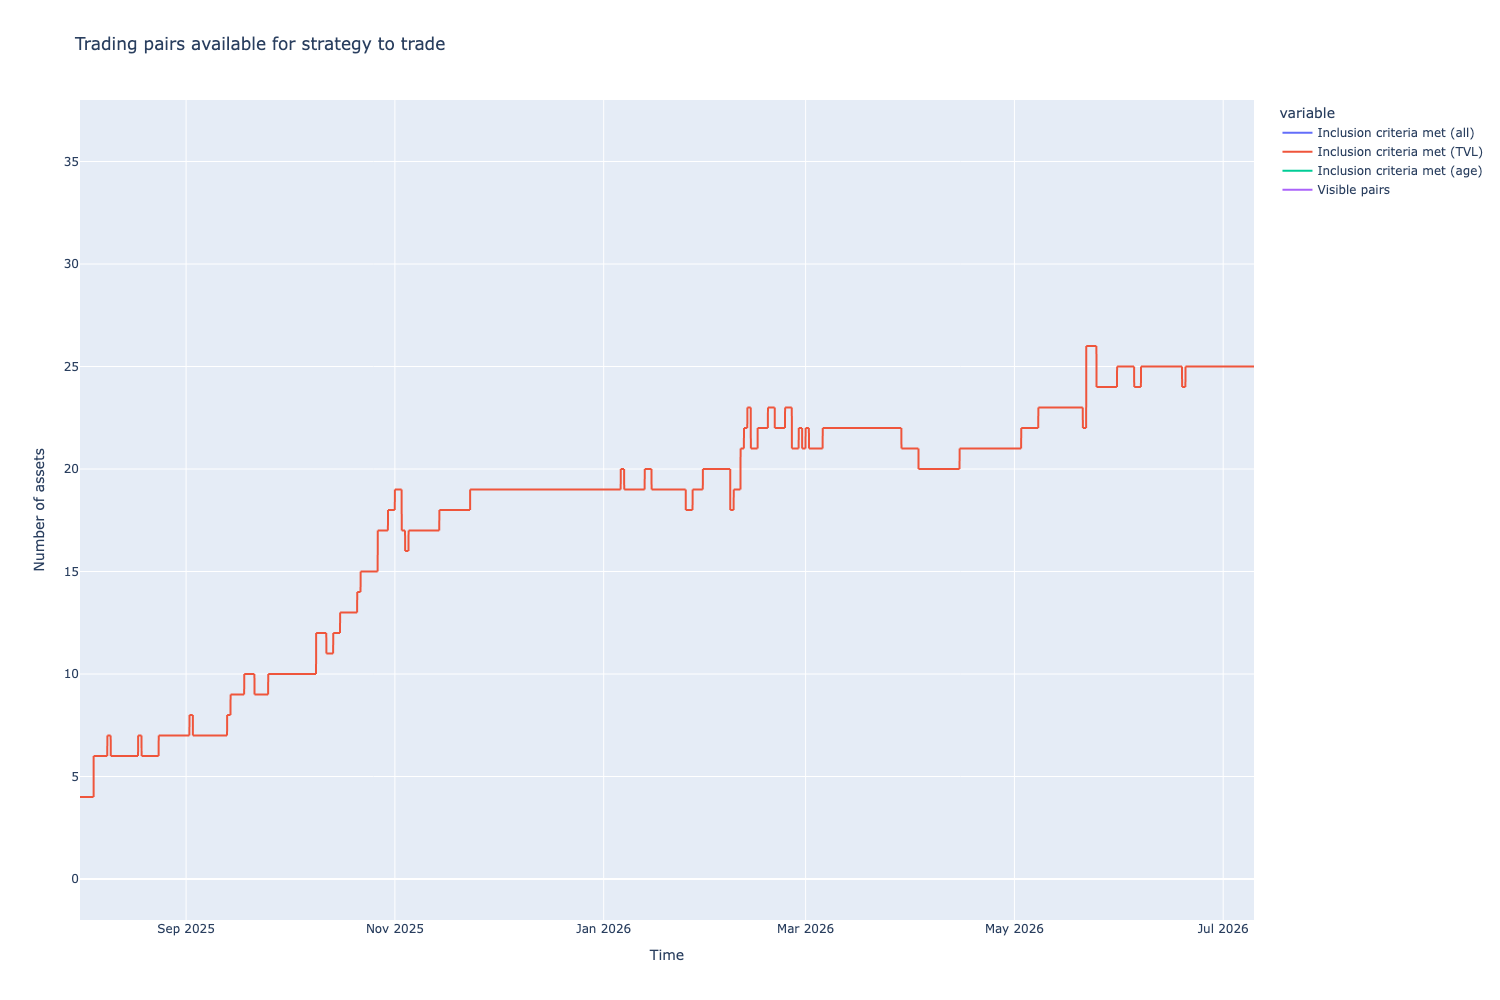

Head (5 rows)


,Inclusion criteria met (all),Inclusion criteria met (TVL),Inclusion criteria met (age),Visible pairs
2021-05-06,0.0,NaN,NaN,NaN
2021-05-07,0.0,NaN,NaN,NaN
2021-05-08,0.0,NaN,NaN,NaN
2021-05-09,0.0,NaN,NaN,NaN
2021-05-10,0.0,NaN,NaN,NaN


Tail (5 rows)


,Inclusion criteria met (all),Inclusion criteria met (TVL),Inclusion criteria met (age),Visible pairs
2026-07-09 20:00:00,NaN,25.0,NaN,NaN
2026-07-09 21:00:00,NaN,25.0,NaN,NaN
2026-07-09 22:00:00,NaN,25.0,NaN,NaN
2026-07-09 23:00:00,NaN,25.0,NaN,NaN
2026-07-10 00:00:00,21.0,25.0,36.0,34.0


In [7]:
fig, df = indicator_chart_renderer.render(available_trading_pairs, with_dataframe=True)
fig.show()
display_head_and_tail(df, head_rows=5, tail_rows=5)


## Included vault details

- Table of when each vault first entered the final investable set, with chain and TVL context.
- This is a detail table for the combined chart above, not a separate inclusion-criteria chart.

In [8]:
df = indicator_chart_renderer.render(inclusion_criteria_check_with_chain)
display_head_and_tail(df, head_rows=5, tail_rows=5)


Head (5 rows)


,Included at,Ticker,Chain,Venue,TVL at inclusion,TVL at end
273443787,2025-03-03,Lighter Liquidity Provider (LLP),lighter,lighter,7.656259e+05,7.572329e+07
284780574,2025-09-20,ETH 3x long,lighter,lighter,6.231042e+04,9.424907e+02
274362569,2025-09-20,HYPE 2x long,lighter,lighter,9.063688e+03,2.631334e+03
274465280,2025-09-20,BTC 3x long,lighter,lighter,1.074646e+04,1.704443e+02
282442597,2025-10-08,Guinea Pool,lighter,lighter,1.278570e+06,1.003723e+05


Tail (5 rows)


,Included at,Ticker,Chain,Venue,TVL at inclusion,TVL at end
281284813,2026-04-20,[ Systemic Strategies ] Peter Schiff's vault,lighter,lighter,764287.012663,736727.412781
274344189,2026-05-19,PHP Trading Desk (BTC/USDC),lighter,lighter,9187.652332,16176.576039
279425033,2026-06-22,pmalt,lighter,lighter,196358.304093,197725.028096
282240367,2026-07-06,Candle Effect v2,lighter,lighter,30558.978454,31034.485335
269511405,2026-07-06,Candle Effect v1,lighter,lighter,10345.463841,10345.463841


# Time range for backtest

- Show how many vaults meet all criteria across the research window.

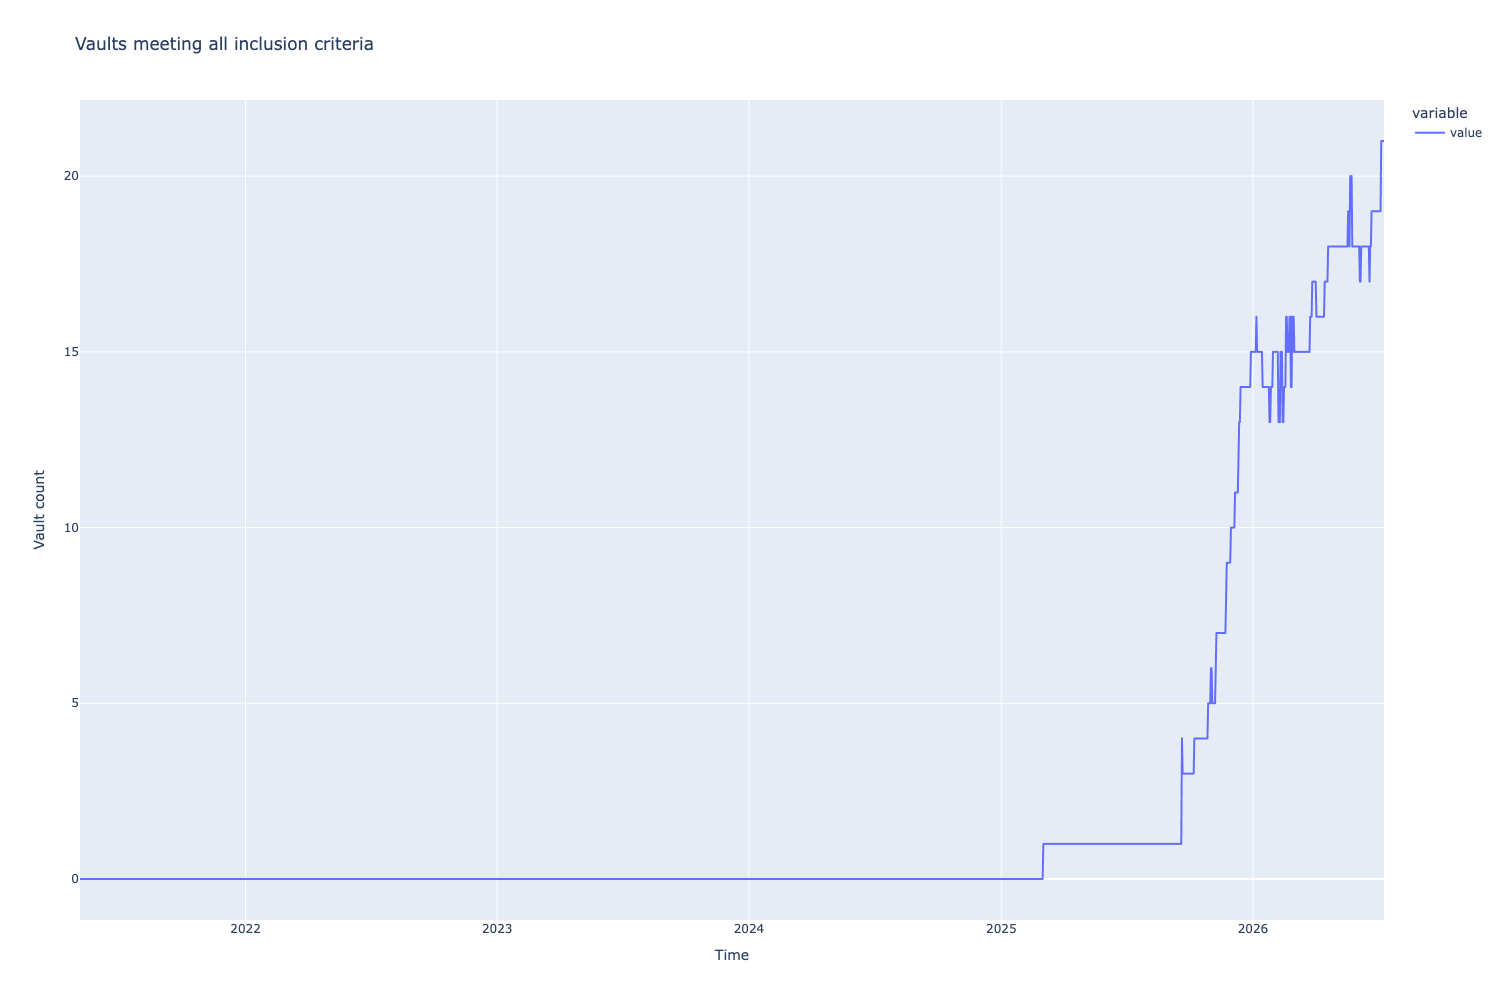

In [9]:
series = indicator_data.get_indicator_series(
    "all_criteria_included_pair_count",
)
fig = px.line(
    series,
    title="Vaults meeting all inclusion criteria",
)
fig.update_yaxes(title="Vault count")
fig.update_xaxes(title="Time")
fig.show()

## Backtest

- Run the Lighter vault-of-vaults backtest without changing the strategy logic or parameters.


In [10]:
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def _extract_optional_int(text: str, label: str) -> int:
    match = re.search(rf"{re.escape(label)}: ([0-9]+)", text)
    return int(match.group(1)) if match else 0


def position_duration_summary(state) -> dict:
    positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
    durations = []
    for position in positions:
        closed_at = position.closed_at if position.closed_at is not None else Parameters.backtest_end
        durations.append((closed_at - position.opened_at).total_seconds() / 86400)
    duration_series = pd.Series(durations, dtype='float64')
    return {
        'position_count': len(positions),
        'positions_lt_3d': int((duration_series < 3).sum()),
        'share_positions_lt_3d': float((duration_series < 3).mean()) if len(duration_series) else float('nan'),
        'median_position_days': float(duration_series.median()) if len(duration_series) else float('nan'),
    }


def extract_selection_diagnostics_df(state) -> pd.DataFrame:
    rows = []
    for unix_ts, messages in sorted(state.visualisation.messages.items(), key=lambda item: item[0]):
        if not messages:
            continue
        message = '\n'.join(messages)
        rows.append(
            {
                'timestamp': datetime.datetime.fromtimestamp(unix_ts, datetime.UTC).replace(tzinfo=None),
                'open_positions': _extract_optional_int(message, 'Open/about to open positions'),
                'candidate_signals_created': _extract_optional_int(message, 'Candidate signals created'),
                'selected_survivor_signals': _extract_optional_int(message, 'Selected survivor signals'),
            }
        )
    return pd.DataFrame(rows).set_index('timestamp')


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    """Gate on positive trailing Sharpe, then rank and allocate by a 0.875-year age ramp."""
    parameters = input.parameters
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)

    gated_candidates = []
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        trailing_sharpe = indicators.get_indicator_value('rolling_sharpe', pair=pair)
        try:
            trailing_sharpe = float(trailing_sharpe)
        except (TypeError, ValueError):
            continue
        if not trailing_sharpe > 0.0:
            continue
        age_ramp_weight = indicators.get_indicator_value('age_ramp_weight', pair=pair)
        try:
            age_ramp_weight = max(float(age_ramp_weight), 0.05)
        except (TypeError, ValueError):
            age_ramp_weight = 0.05
        gated_candidates.append((pair_id, pair, age_ramp_weight))

    gated_candidates.sort(key=lambda item: (-item[2], item[0]))
    selected_candidates = gated_candidates[:parameters.max_assets_in_portfolio]

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for _pair_id, pair, age_ramp_weight in selected_candidates:
        alpha_model.set_signal(pair, max(age_ramp_weight, 1e-12))

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(
        position_manager,
        parameters.allocation_pct,
    )

    alpha_model.select_top_signals(count=len(selected_candidates))
    alpha_model.assign_weights(method=weight_passthrouh)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=parameters.per_position_cap_of_pool_pct,
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=parameters.max_concentration_pct,
        max_positions=parameters.max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
        # Scale buys down to the sells that actually execute this cycle, so a
        # large underweight buy funded by several sub-threshold trims cannot
        # overspend the reserve (OutOfSimulatedBalance in backtest, a bounced
        # deposit live).
        cap_buys_to_sync_cash=True,
        sync_cash_headroom_usd=parameters.sync_cash_headroom_usd,
    )
    state.visualisation.add_calculations(
        timestamp,
        {'unallocatable_signals': alpha_model.get_unallocatable_signals()},
    )

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(
            f"""
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Positive trailing-Sharpe gate survivors: {len(gated_candidates)}
            Candidate signals created: {len(gated_candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Weight signal: {parameters.weight_signal}
            Trailing Sharpe lookback: {parameters.sharpe_lookback_days} days
            Age ramp period: {parameters.age_ramp_period}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            """
        )

        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(
                f"""
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                """
            )

        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'

        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


result = run_backtest_inline(
    name=Parameters.id,
    engine_version='0.5',
    decide_trades=decide_trades,
    create_indicators=indicators.create_indicators,
    cycle_duration=CycleDuration.from_timebucket(parameters.candle_time_bucket),
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)

state = result.state
selection_diagnostics_df = extract_selection_diagnostics_df(state)
duration_summary = position_duration_summary(state)

equity_curve = calculate_equity_curve(state)
returns = calculate_returns(equity_curve)
summary_df = pd.DataFrame(
    [
        {
            'Cumulative return': equity_curve.iloc[-1] / equity_curve.iloc[0] - 1,
            'CAGR': calculate_cagr(returns),
            'Sharpe': calculate_sharpe(returns, periods=365),
            'Sortino': calculate_sortino(returns, periods=365),
            'Max DD': calculate_max_drawdown(returns),
            'Trades': len(list(state.portfolio.get_all_trades())),
            'Positions': duration_summary['position_count'],
            'Final candidate signals': selection_diagnostics_df['candidate_signals_created'].iloc[-1],
            'Final selected survivors': selection_diagnostics_df['selected_survivor_signals'].iloc[-1],
            'Mean candidate signals': selection_diagnostics_df['candidate_signals_created'].mean(),
            'Mean selected survivors': selection_diagnostics_df['selected_survivor_signals'].mean(),
            'Positions < 3d': duration_summary['positions_lt_3d'],
            'Share positions < 3d': duration_summary['share_positions_lt_3d'],
            'Median position days': duration_summary['median_position_days'],
        }
    ]
)
display(summary_df)


,Cumulative return,CAGR,Sharpe,Sortino,Max DD,Trades,Positions,Final candidate signals,Final selected survivors,Mean candidate signals,Mean selected survivors,Positions < 3d,Share positions < 3d,Median position days
0,0.205954,0.221238,0.701986,1.117555,-0.266457,1985,99,18,18,7.22449,7.451895,42,0.424242,3.0


## Latest cycle cash and redemption snapshot

In [11]:
import re
import pandas as pd


def _extract_optional_usd(text: str, label: str) -> float:
    match = re.search(rf"{re.escape(label)}: ([0-9,]+(?:\.[0-9]+)?) USD", text)
    return float(match.group(1).replace(',', '')) if match else float('nan')


message_map = state.visualisation.get_messages_tail(2)
latest_cycle_label = list(message_map.keys())[0]
latest_message = list(message_map.values())[0]

if 'chart_renderer' not in globals():
    chart_renderer = ChartBacktestRenderingSetup(
        registry=charts,
        strategy_input_indicators=indicator_data,
        state=state,
        backtest_start_at=Parameters.backtest_start,
        backtest_end_at=Parameters.backtest_end,
    )

alpha_df = chart_renderer.render(alpha_model_diagnostics)
if isinstance(alpha_df.columns, pd.MultiIndex):
    alpha_df.columns = [c[0] for c in alpha_df.columns]

accepted_size_col = next(c for c in alpha_df.columns if 'Accepted size' in str(c))
flags_col = next(c for c in alpha_df.columns if 'Flags' in str(c))

accepted_sizes = pd.to_numeric(alpha_df[accepted_size_col], errors='coerce').fillna(0.0)
accepted_mask = accepted_sizes > 0
flags = alpha_df[flags_col].fillna('').astype(str)

total_equity = _extract_optional_usd(latest_message, 'Total equity')
cash = _extract_optional_usd(latest_message, 'Cash')
redeemable_capital = _extract_optional_usd(latest_message, 'Redeemable capital')
pending_redemptions = _extract_optional_usd(latest_message, 'Pending redemptions')
investable = _extract_optional_usd(latest_message, 'Investable equity')
accepted_investable = _extract_optional_usd(latest_message, 'Accepted investable equity')
allocated_to_signals = _extract_optional_usd(latest_message, 'Allocated to signals')
discarded_lit_liquidity = _extract_optional_usd(latest_message, 'Discarded allocation because of lack of lit liquidity')

benchmark_df = pd.DataFrame(
    [
        ('Final cycle', latest_cycle_label),
        ('Total equity USD', total_equity),
        ('Cash USD', cash),
        ('Cash % of equity', cash / total_equity if total_equity else float('nan')),
        ('Redeemable capital USD', redeemable_capital),
        ('Pending redemptions USD', pending_redemptions),
        ('Investable equity USD', investable),
        ('Accepted investable equity USD', accepted_investable),
        ('Accepted / investable %', accepted_investable / investable if investable else float('nan')),
        ('Allocated to signals USD', allocated_to_signals),
        ('Discarded because of lit liquidity USD', discarded_lit_liquidity),
        ('Unaccepted investable USD', investable - accepted_investable),
        ('Unaccepted / investable %', (investable - accepted_investable) / investable if investable else float('nan')),
        ('Accepted positions', int(accepted_mask.sum())),
        ('Mean accepted position USD', accepted_sizes[accepted_mask].mean()),
        ('Median accepted position USD', accepted_sizes[accepted_mask].median()),
        ('Flags: capped_by_pool_size', int(flags.str.contains('capped_by_pool_size').sum())),
        ('Flags: individual_trade_size_too_small', int(flags.str.contains('individual_trade_size_too_small').sum())),
    ],
    columns=['Metric', 'Value'],
)

display(benchmark_df)


,Metric,Value
0,Final cycle,2026-07-09 00:00:00
1,Total equity USD,120595.37
2,Cash USD,2441.37
3,Cash % of equity,0.020244
4,Redeemable capital USD,118154.0
5,Pending redemptions USD,0.0
6,Investable equity USD,118183.46
7,Accepted investable equity USD,118183.46
8,Accepted / investable %,1.0
9,Allocated to signals USD,118183.46


## Capital utilisation through time

In [12]:
import datetime
import re
import pandas as pd


def _extract_optional_usd_series(text: str, label: str) -> float:
    match = re.search(rf"{re.escape(label)}: ([0-9,]+(?:\.[0-9]+)?) USD", text)
    return float(match.group(1).replace(',', '')) if match else float('nan')


def _extract_optional_int_series(text: str, label: str) -> int:
    match = re.search(rf"{re.escape(label)}: ([0-9]+)", text)
    return int(match.group(1)) if match else 0


rows = []
message_tuples = sorted(state.visualisation.messages.items(), key=lambda x: x[0])
for unix_ts, messages in message_tuples:
    if not messages:
        continue
    message = '\n'.join(messages)
    dt = datetime.datetime.fromtimestamp(unix_ts, datetime.UTC).replace(tzinfo=None)
    total_equity = _extract_optional_usd_series(message, 'Total equity')
    cash = _extract_optional_usd_series(message, 'Cash')
    redeemable = _extract_optional_usd_series(message, 'Redeemable capital')
    pending = _extract_optional_usd_series(message, 'Pending redemptions')
    investable = _extract_optional_usd_series(message, 'Investable equity')
    accepted = _extract_optional_usd_series(message, 'Accepted investable equity')
    allocated = _extract_optional_usd_series(message, 'Allocated to signals')
    discarded = _extract_optional_usd_series(message, 'Discarded allocation because of lack of lit liquidity')
    rows.append({
        'timestamp': dt,
        'total_equity_usd': total_equity,
        'cash_usd': cash,
        'cash_pct_of_equity': cash / total_equity if total_equity else float('nan'),
        'redeemable_capital_usd': redeemable,
        'pending_redemptions_usd': pending,
        'investable_equity_usd': investable,
        'accepted_investable_equity_usd': accepted,
        'accepted_pct_of_investable': accepted / investable if investable else float('nan'),
        'unaccepted_pct_of_investable': (investable - accepted) / investable if investable else float('nan'),
        'allocated_to_signals_usd': allocated,
        'discarded_due_to_lit_liquidity_usd': discarded,
        'capped_by_pool_size_count': _extract_optional_int_series(message, 'Signals with flag capped_by_pool_size'),
        'individual_trade_size_too_small_count': _extract_optional_int_series(message, 'Signals with flag individual_trade_size_too_small'),
    })

utilisation_df = pd.DataFrame(rows).set_index('timestamp')
display(utilisation_df.tail(10))


,total_equity_usd,cash_usd,cash_pct_of_equity,redeemable_capital_usd,pending_redemptions_usd,investable_equity_usd,accepted_investable_equity_usd,accepted_pct_of_investable,unaccepted_pct_of_investable,allocated_to_signals_usd,discarded_due_to_lit_liquidity_usd,capped_by_pool_size_count,individual_trade_size_too_small_count
timestamp,,,,,,,,,,,,,
2026-06-30,119357.68,4772.67,0.039986,114585.00,0.0,116970.52,116970.52,1.000000,0.000000,116970.52,37656.24,6,3
2026-07-01,119982.86,2412.98,0.020111,117569.87,0.0,117583.20,117583.20,1.000000,0.000000,117583.20,35433.94,6,5
2026-07-02,121875.40,2490.20,0.020432,119385.20,0.0,119437.89,115376.58,0.965996,0.034004,115376.58,30736.54,6,3
2026-07-03,121827.63,6525.13,0.053560,115302.50,0.0,119391.07,119391.07,1.000000,0.000000,119391.07,26865.18,6,2
2026-07-04,121005.80,2462.86,0.020353,118542.94,0.0,118585.69,118585.69,1.000000,0.000000,118585.69,26474.19,6,2
2026-07-05,121617.08,2488.03,0.020458,119129.05,0.0,119184.74,119184.74,1.000000,0.000000,119184.74,25875.04,6,7
2026-07-06,120765.89,2581.46,0.021376,118184.43,0.0,118350.57,118350.57,1.000000,0.000000,118350.57,24374.25,6,2
2026-07-07,121098.78,2482.66,0.020501,118616.12,0.0,118676.81,118676.81,1.000000,0.000000,118676.81,26613.97,8,3
2026-07-08,120781.83,2488.58,0.020604,118293.25,0.0,118366.19,118366.19,1.000000,0.000000,118366.19,22426.32,8,2


## Capital utilisation summary

In [13]:
utilisation_summary = pd.DataFrame(
    [
        ('Mean accepted / investable %', utilisation_df['accepted_pct_of_investable'].mean()),
        ('Median accepted / investable %', utilisation_df['accepted_pct_of_investable'].median()),
        ('Min accepted / investable %', utilisation_df['accepted_pct_of_investable'].min()),
        ('Max accepted / investable %', utilisation_df['accepted_pct_of_investable'].max()),
        ('Mean cash % of equity', utilisation_df['cash_pct_of_equity'].mean()),
        ('Median cash % of equity', utilisation_df['cash_pct_of_equity'].median()),
        ('Max cash % of equity', utilisation_df['cash_pct_of_equity'].max()),
        ('Mean redeemable capital USD', utilisation_df['redeemable_capital_usd'].mean()),
        ('Mean pending redemptions USD', utilisation_df['pending_redemptions_usd'].mean()),
        ('Mean capped_by_pool_size count', utilisation_df['capped_by_pool_size_count'].mean()),
        ('Mean too-small count', utilisation_df['individual_trade_size_too_small_count'].mean()),
        ('Share of cycles above 50% deployment', (utilisation_df['accepted_pct_of_investable'] > 0.50).mean()),
        ('Share of cycles above 75% deployment', (utilisation_df['accepted_pct_of_investable'] > 0.75).mean()),
    ],
    columns=['Metric', 'Value'],
)
display(utilisation_summary)


,Metric,Value
0,Mean accepted / investable %,0.803857
1,Median accepted / investable %,1.000000
2,Min accepted / investable %,0.200000
3,Max accepted / investable %,1.000000
4,Mean cash % of equity,0.215078
5,Median cash % of equity,0.020832
6,Max cash % of equity,1.000000
7,Mean redeemable capital USD,80014.238892
8,Mean pending redemptions USD,0.000000
9,Mean capped_by_pool_size count,1.854227


## Capital utilisation charts

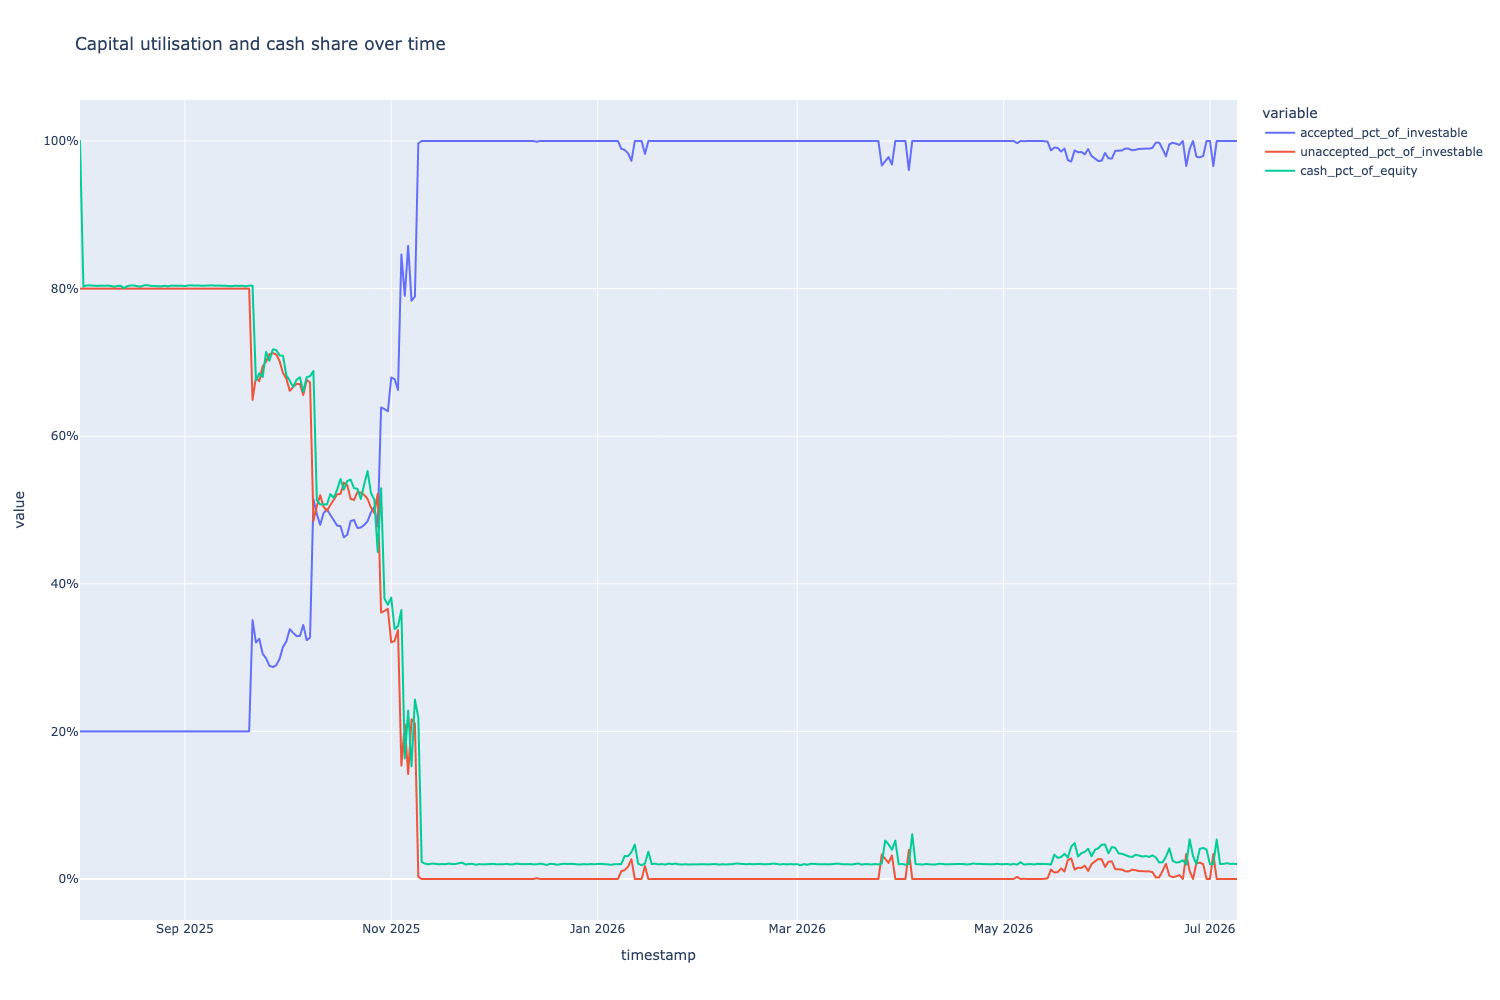

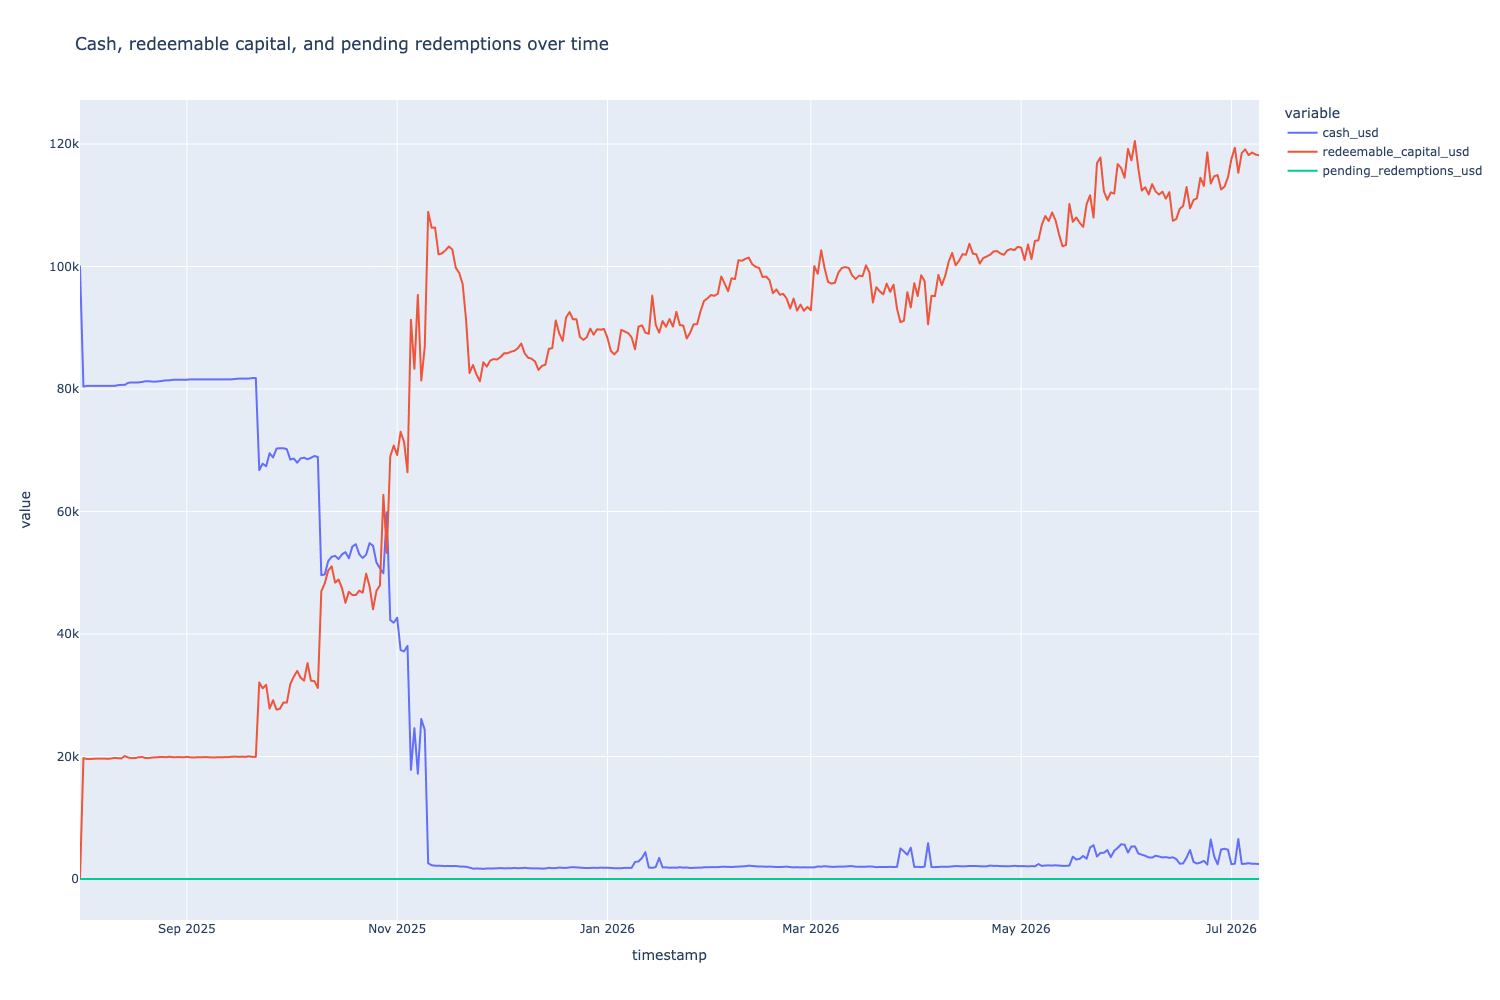

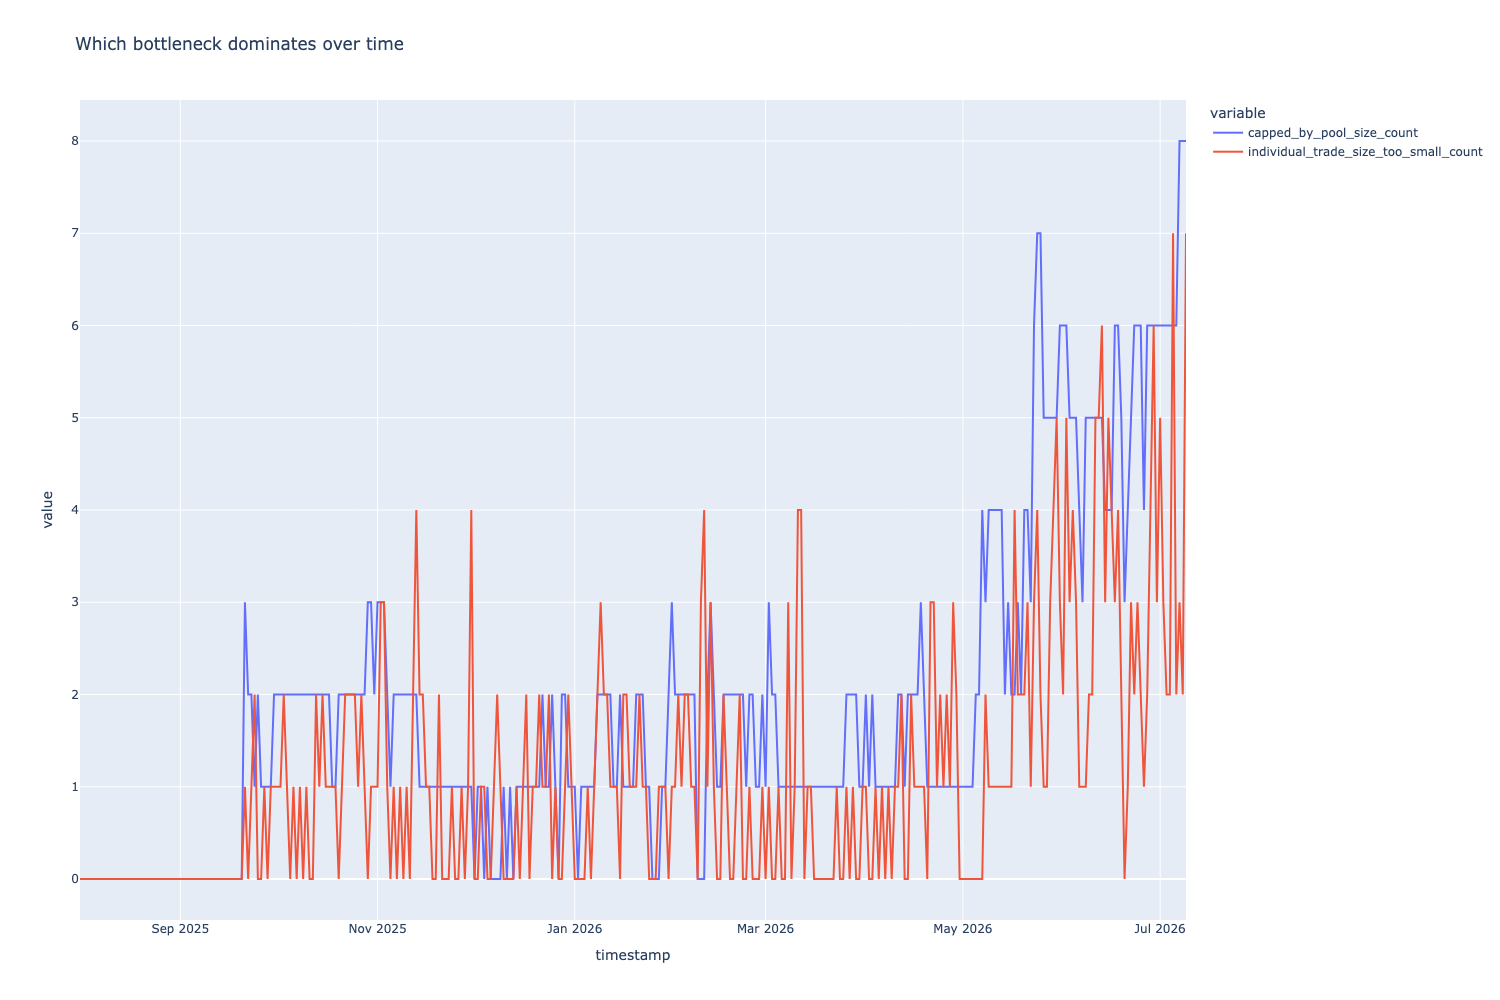

In [14]:
import plotly.express as px

plot_df = utilisation_df.reset_index()

fig = px.line(
    plot_df,
    x='timestamp',
    y=['accepted_pct_of_investable', 'unaccepted_pct_of_investable', 'cash_pct_of_equity'],
    title='Capital utilisation and cash share over time',
)
fig.update_yaxes(tickformat='.0%')
fig.show()

fig = px.line(
    plot_df,
    x='timestamp',
    y=['cash_usd', 'redeemable_capital_usd', 'pending_redemptions_usd'],
    title='Cash, redeemable capital, and pending redemptions over time',
)
fig.show()

fig = px.line(
    plot_df,
    x='timestamp',
    y=['capped_by_pool_size_count', 'individual_trade_size_too_small_count'],
    title='Which bottleneck dominates over time',
)
fig.show()


## Survivor selection

Head (5 rows)


,open_positions,candidate_signals_created,selected_survivor_signals
timestamp,,,
2025-08-01,1,1,1
2025-08-02,1,1,1
2025-08-03,1,1,1
2025-08-04,1,1,1
2025-08-05,1,1,1


Tail (5 rows)


,open_positions,candidate_signals_created,selected_survivor_signals
timestamp,,,
2026-07-05,15,15,15
2026-07-06,15,15,15
2026-07-07,18,17,18
2026-07-08,18,18,18
2026-07-09,18,18,18


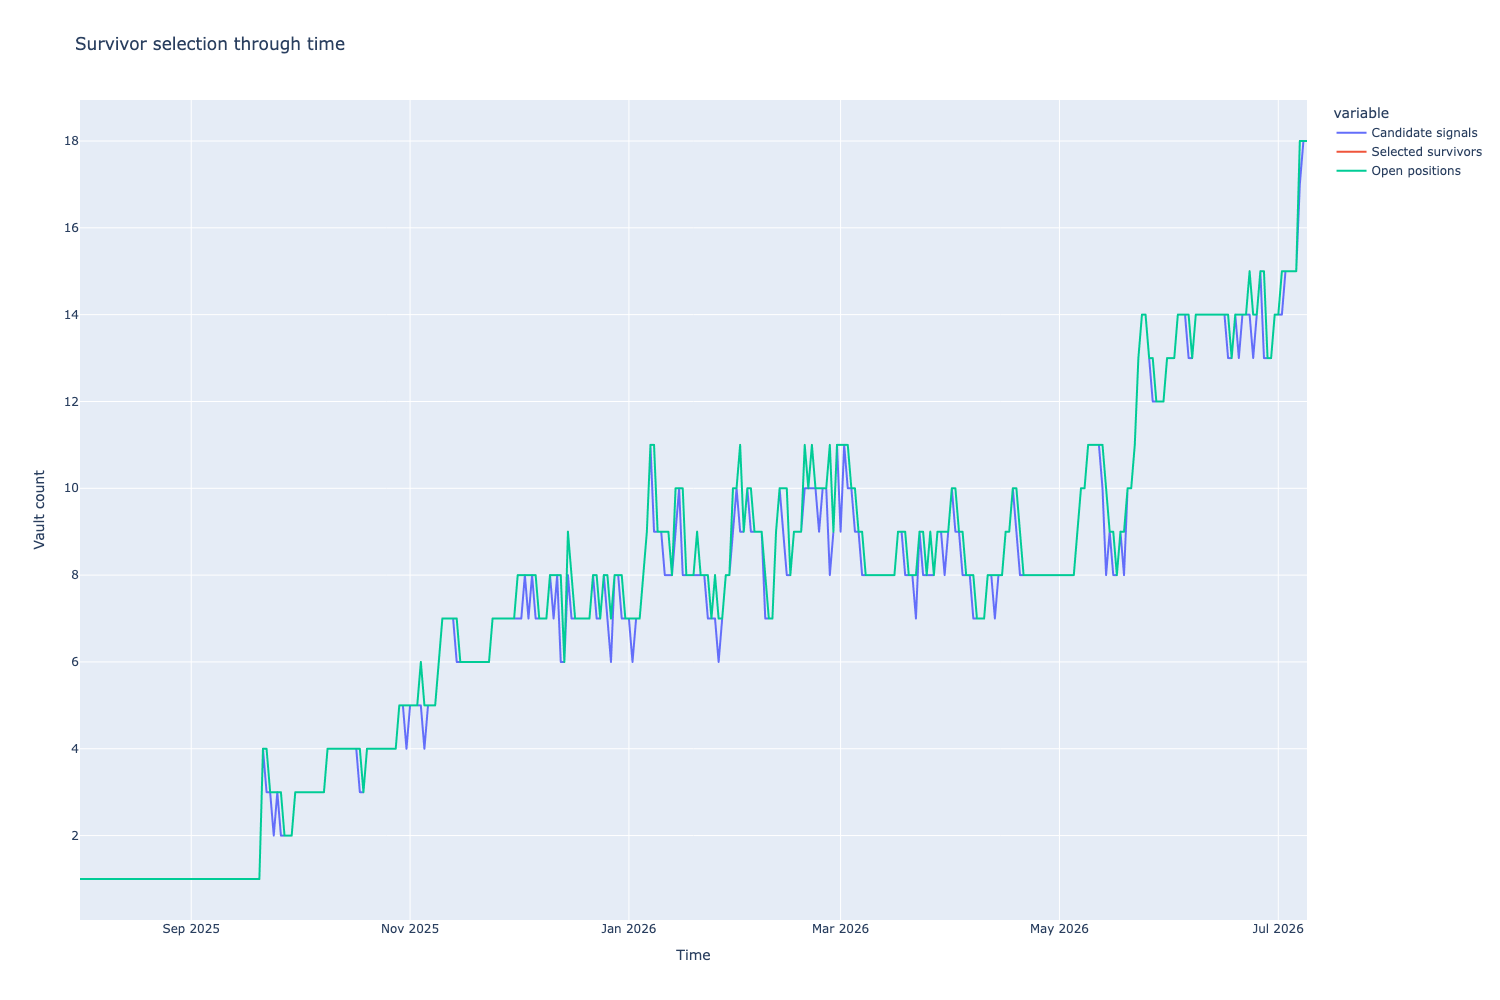

In [15]:
display_head_and_tail(selection_diagnostics_df, head_rows=5, tail_rows=5)

plot_df = selection_diagnostics_df.reset_index().rename(
    columns={
        'candidate_signals_created': 'Candidate signals',
        'selected_survivor_signals': 'Selected survivors',
        'open_positions': 'Open positions',
    }
)
fig = px.line(
    plot_df,
    x='timestamp',
    y=['Candidate signals', 'Selected survivors', 'Open positions'],
    title='Survivor selection through time',
)
fig.update_yaxes(title='Vault count')
fig.update_xaxes(title='Time')
fig.show()


# Performance summary

- Start with the notebook-specific summary table, then inspect the standard strategy performance view.

In [16]:
chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    state=state,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)

display(summary_df)

df = chart_renderer.render(performance_metrics)
display(df)


,Cumulative return,CAGR,Sharpe,Sortino,Max DD,Trades,Positions,Final candidate signals,Final selected survivors,Mean candidate signals,Mean selected survivors,Positions < 3d,Share positions < 3d,Median position days
0,0.205954,0.221238,0.701986,1.117555,-0.266457,1985,99,18,18,7.22449,7.451895,42,0.424242,3.0


,Strategy,BTC,ETH
Start Period,2025-08-01,2025-08-01,2025-08-01
End Period,2026-07-09,2026-07-09,2026-07-09
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,100.0%,100.0%,100.0%
Cumulative Return,20.6%,-44.13%,-49.98%
CAGR﹪,22.12%,-46.27%,-52.25%
Sharpe,0.7,-1.19,-0.76
Prob. Sharpe Ratio,75.54%,12.32%,23.04%
Smart Sharpe,0.61,-1.04,-0.67
Sortino,1.12,-1.58,-1.07


# Equity curve

- Compare the strategy equity curve against the ETH benchmark.

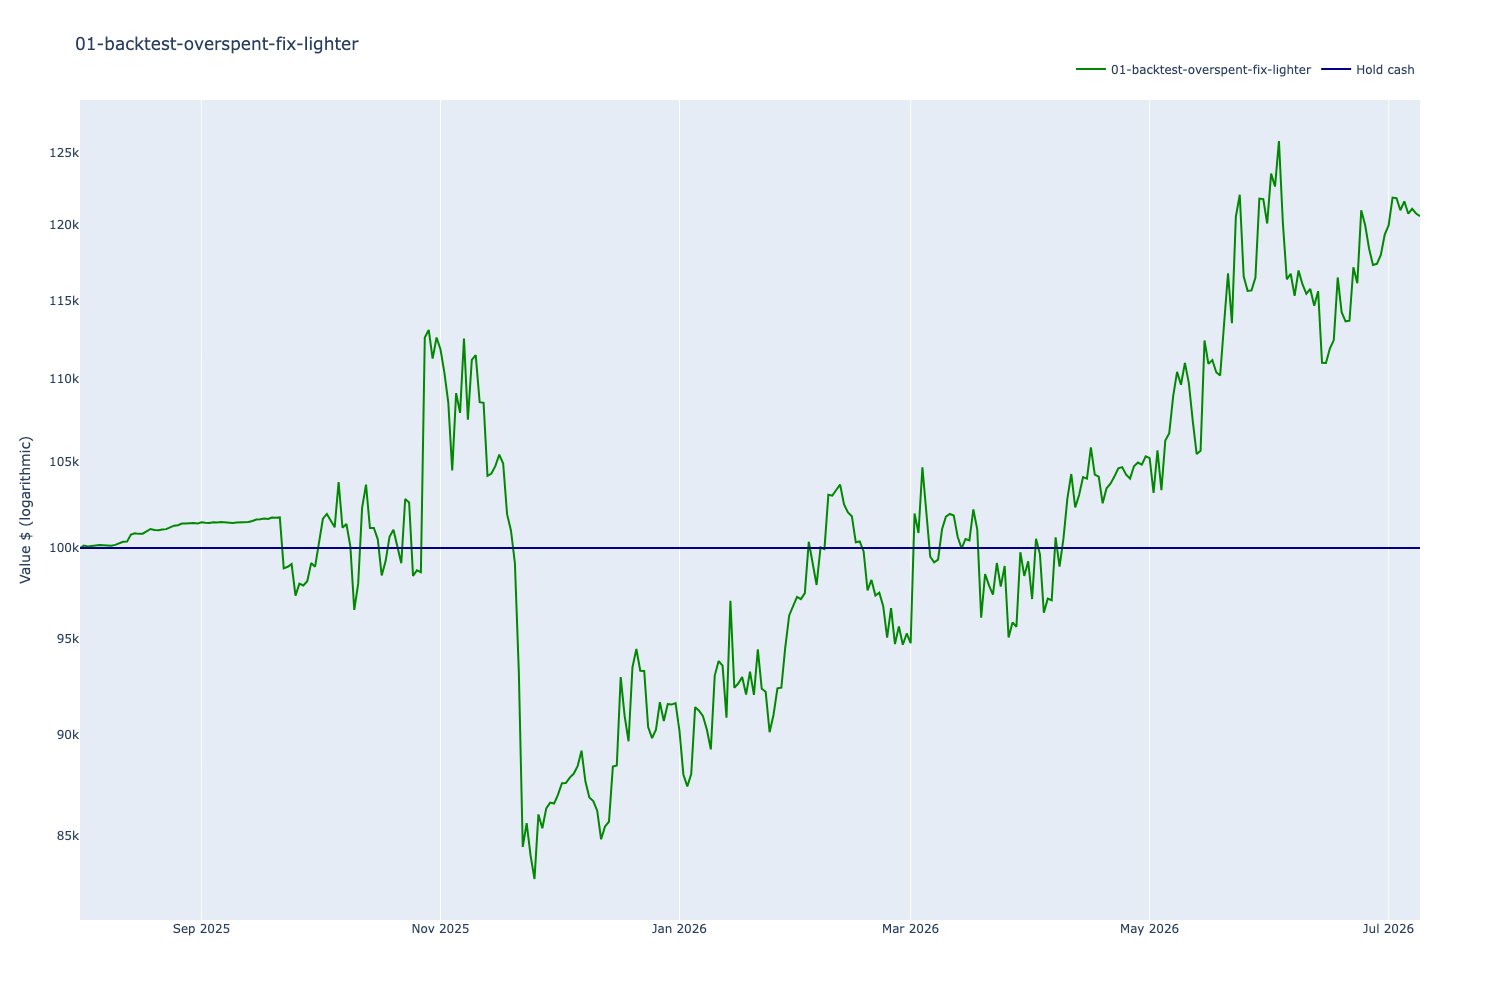

In [17]:
fig = chart_renderer.render(equity_curve_with_benchmark)
fig.show()

## Equity curve with drawdown

- View the same equity path with drawdown overlaid.

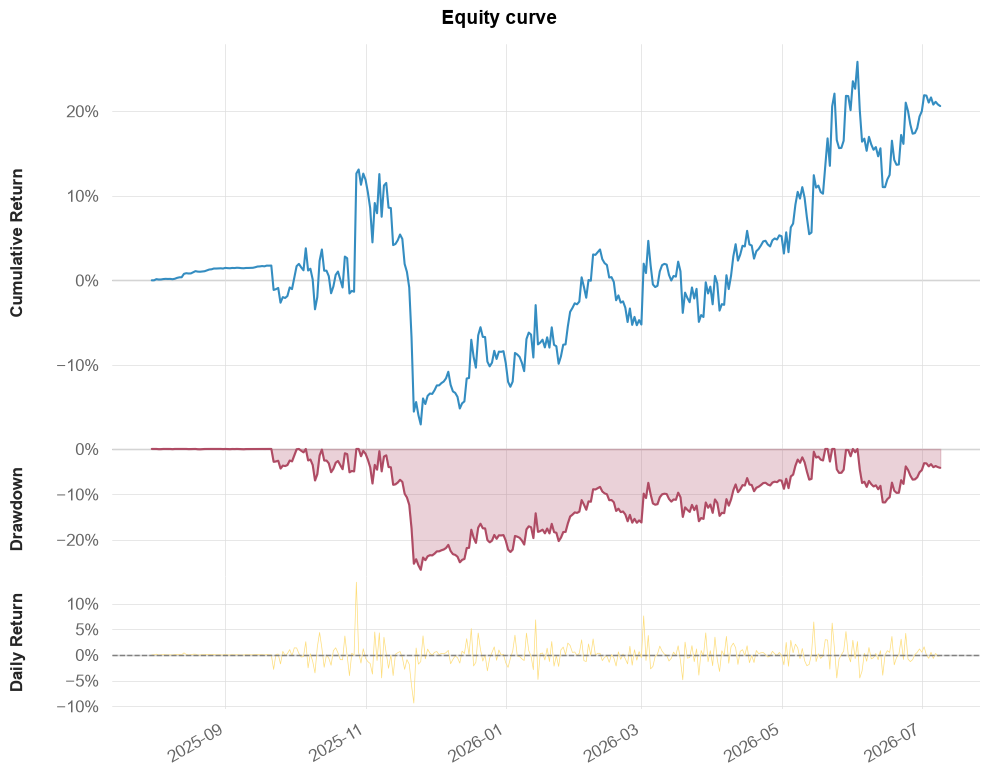

In [18]:
fig = chart_renderer.render(equity_curve_with_drawdown)
display(fig)

# Asset weights

- Review how the portfolio distributes risk across vaults and chains.

## Portfolio equity curve breakdown by asset

- Show how the main vault holdings contribute to the cumulative equity curve.

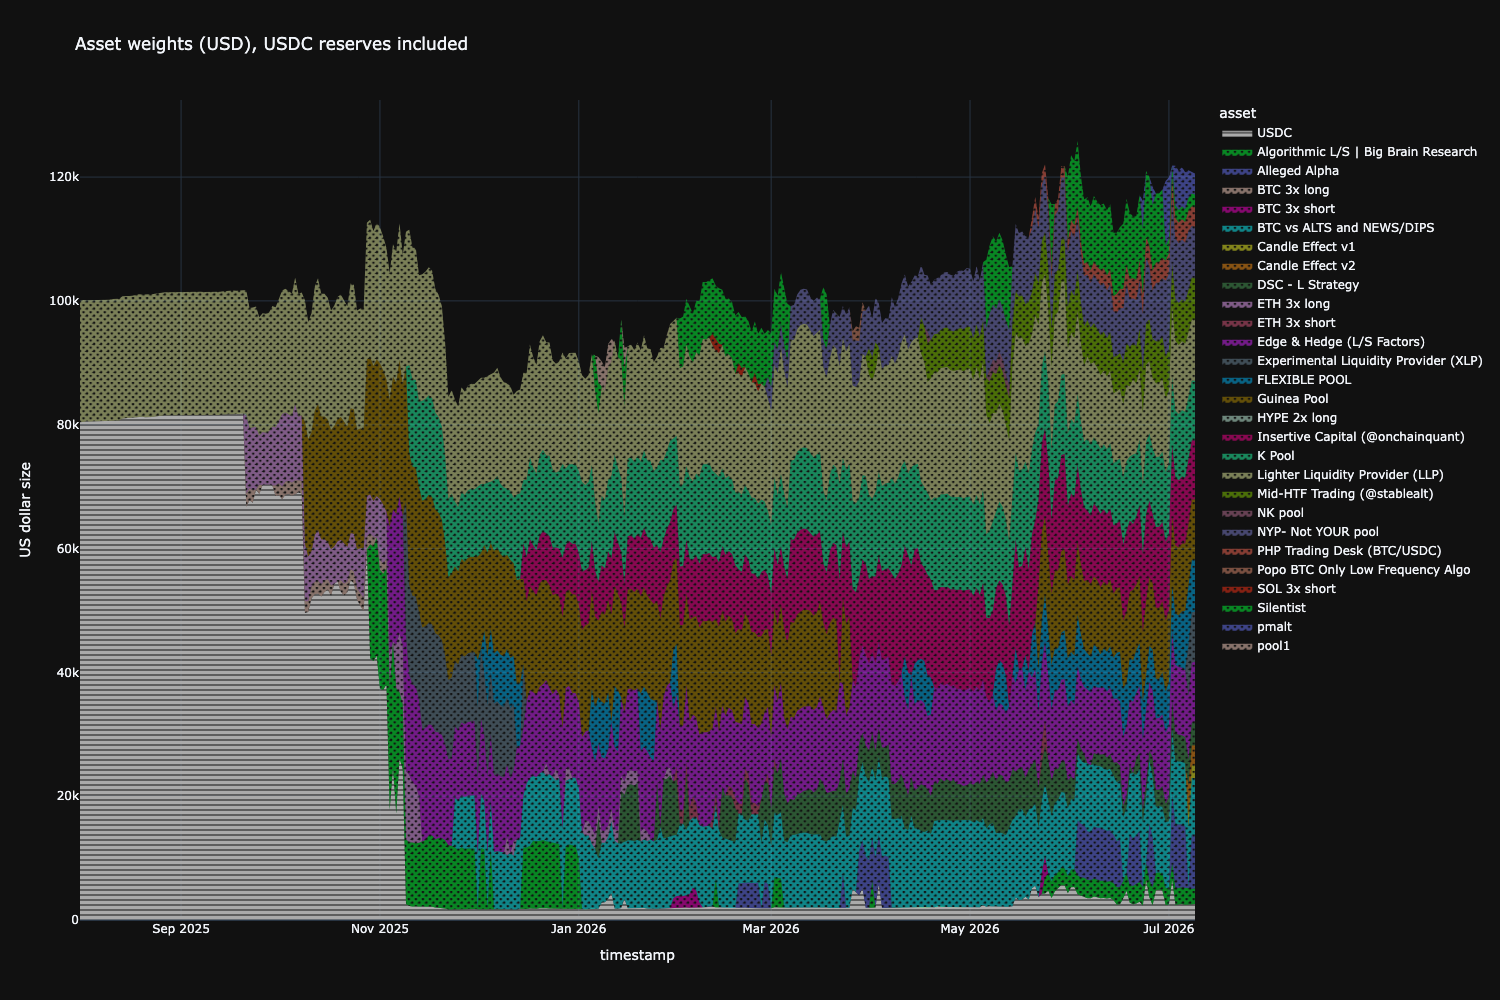

In [19]:
fig = chart_renderer.render(equity_curve_by_asset)
display(fig)

## Skipped signals

- Allocation weight that was selected but could not be deposited because its vault was closed.

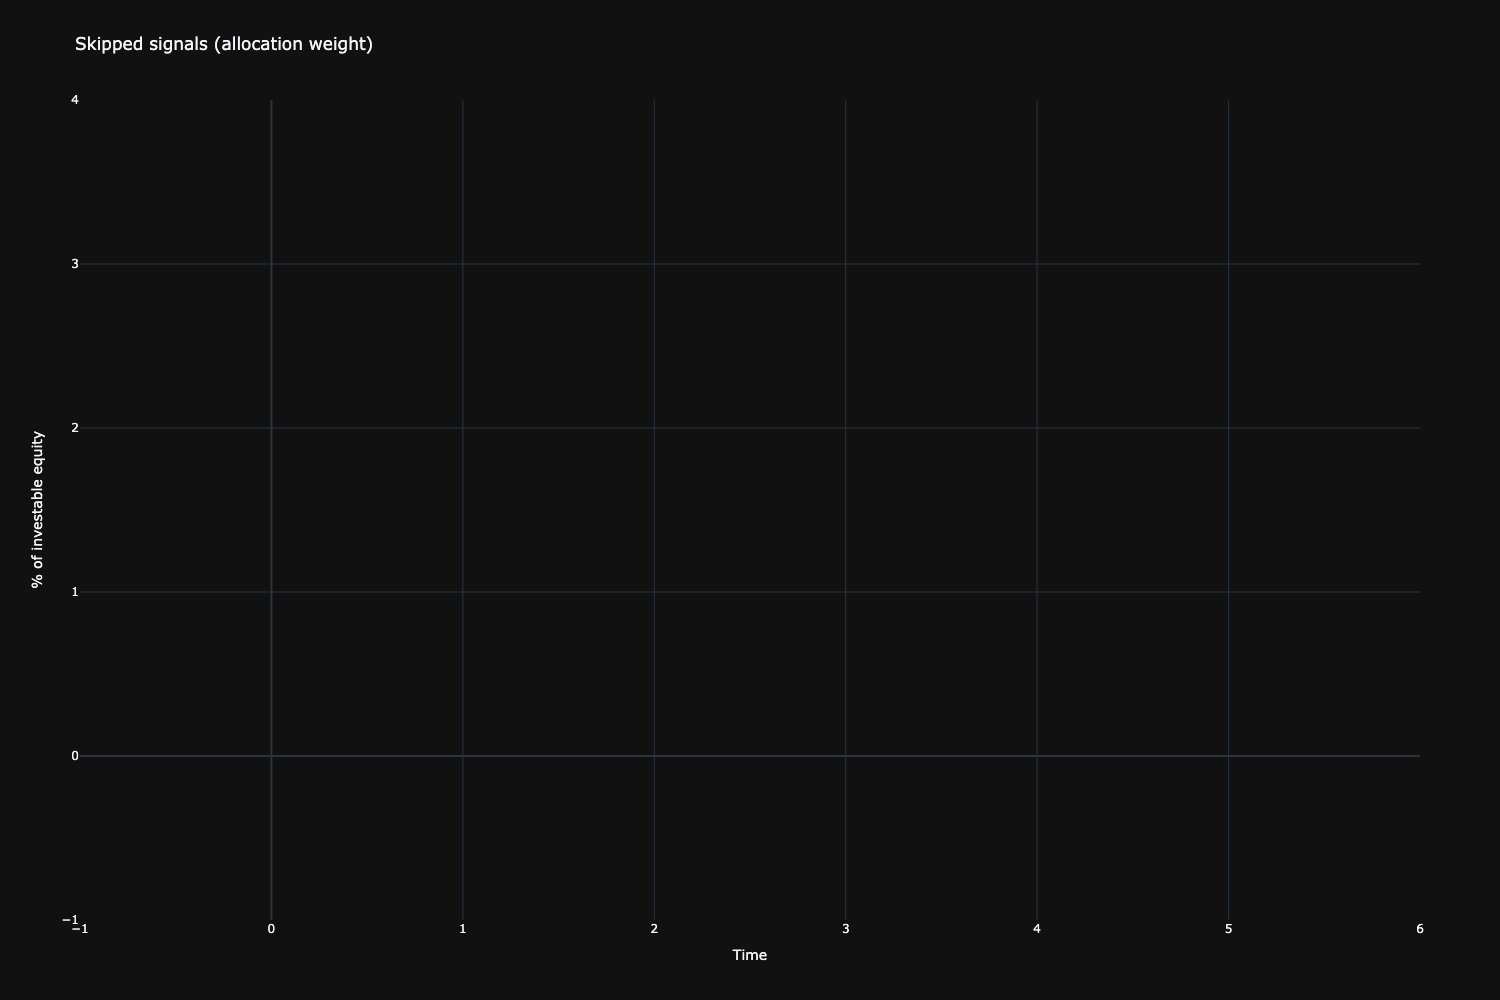

In [20]:
fig = chart_renderer.render(skipped_signals)
display(fig)

## Portfolio equity curve breakdown by chain

- Break the realised equity curve down by chain exposure.

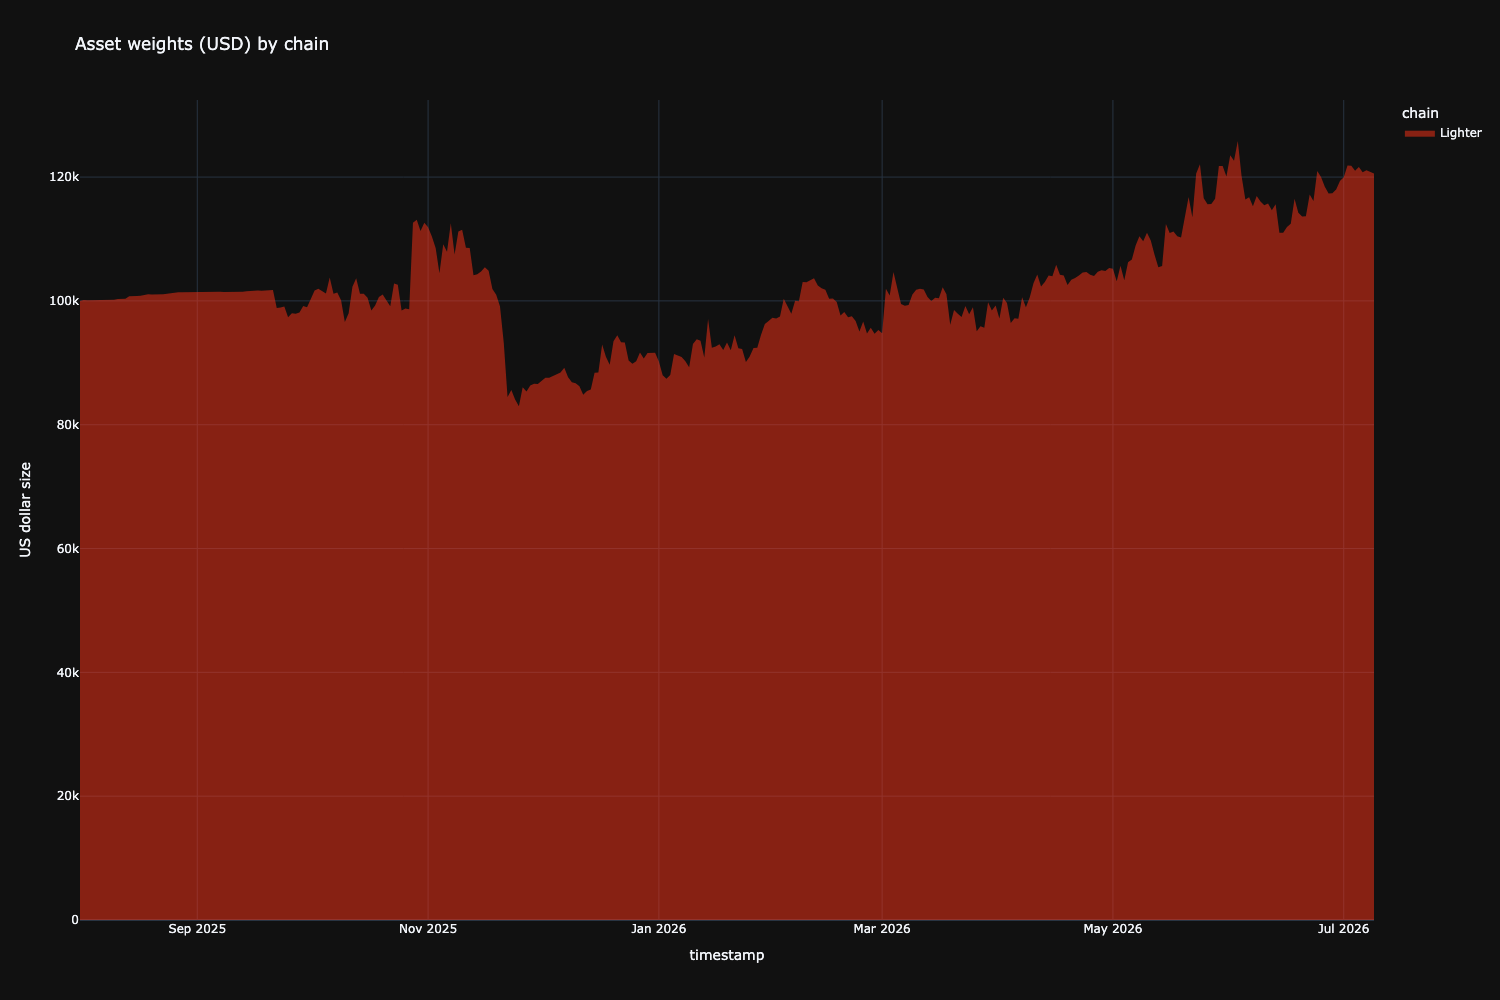

In [21]:
fig, chain_breakdown_df = chart_renderer.render(equity_curve_by_chain)
fig.show()



## Weight allocation statistics

- Keep the compact allocation statistics table as a quick summary.

In [22]:
from tradeexecutor.utils.notebook import display_dataframe_with_html

stats = chart_renderer.render(weight_allocation_statistics)
display_dataframe_with_html(stats)

,At,Pair,Value,Address
Name,,,,
Max position (excluding USDC),2025-10-29,Guinea Pool,"$22,167.75",
Min position (excluding USDC),2025-09-21,HYPE 2x long,$333.74,
Mean position (excluding USDC),,,"$11,128.21",
Max position (excluding USDC),2025-08-01,Lighter Liquidity Provider (LLP),100.00%,
Min position (excluding USDC),2026-04-03,Mid-HTF Trading (@stablealt),0.64%,
Mean position (excluding USDC),,,13.86%,
Max position (including USDC),2025-08-20,USDC,80.45%,
Min position (including USDC),2025-09-21,HYPE 2x long,0.33%,
Mean position (including USDC),,,12.17%,


# Rolling performance

- Track the medium-term return profile and risk-adjusted return profile through time using a fixed 3-month window.


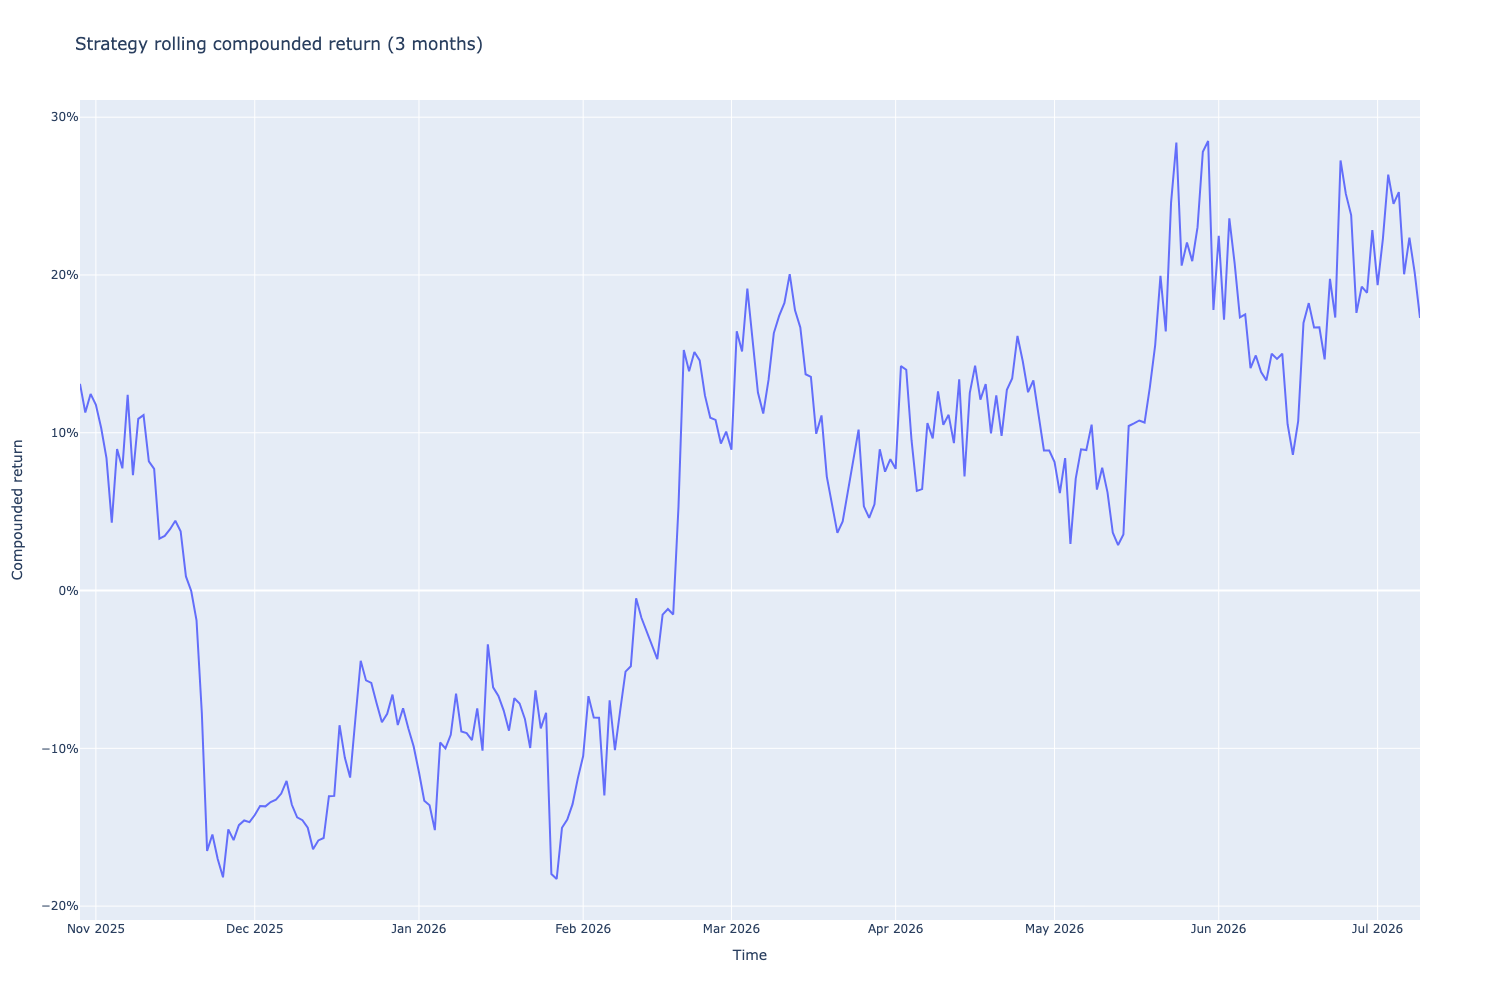

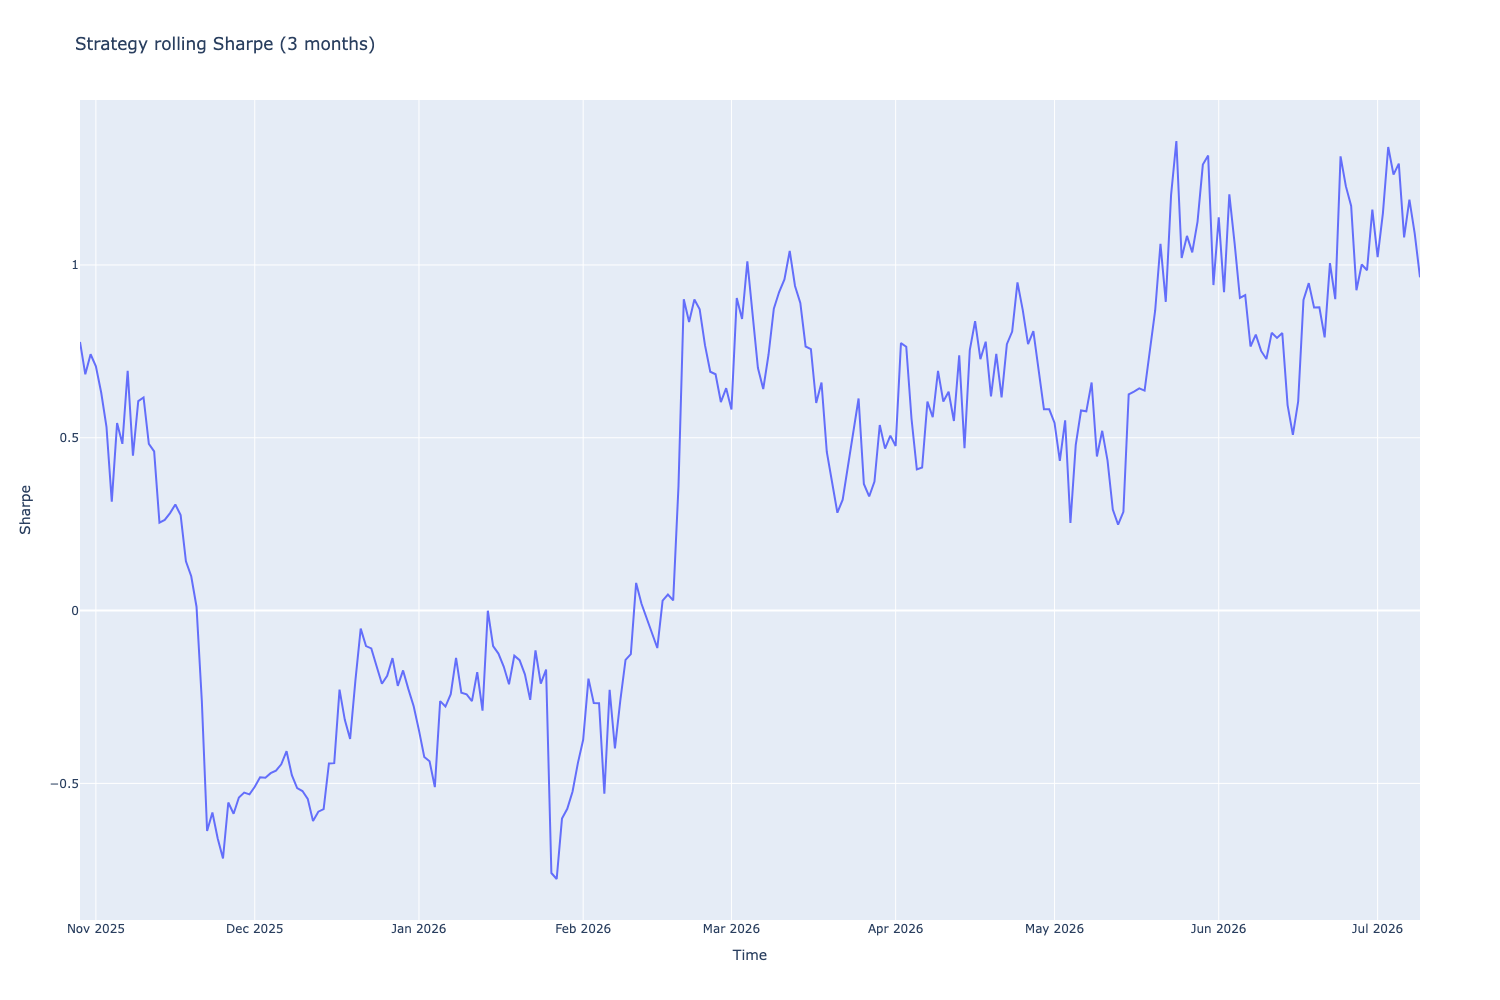

In [23]:
from tradeexecutor.visual.equity_curve import (
    calculate_rolling_returns,
    calculate_rolling_sharpe,
)

rolling_returns = calculate_rolling_returns(
    returns,
    freq="D",
    periods=90,
)

fig = px.line(rolling_returns, title="Strategy rolling compounded return (3 months)")
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Compounded return", tickformat=".0%")
fig.update_xaxes(title="Time")
fig.show()

rolling_sharpe = calculate_rolling_sharpe(
    returns,
    freq="D",
    periods=90,
)

fig = px.line(rolling_sharpe, title="Strategy rolling Sharpe (3 months)")
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Sharpe")
fig.update_xaxes(title="Time")
fig.show()


# Monthly returns

- Check whether the path of returns is broad-based across months or dominated by a few bursts.


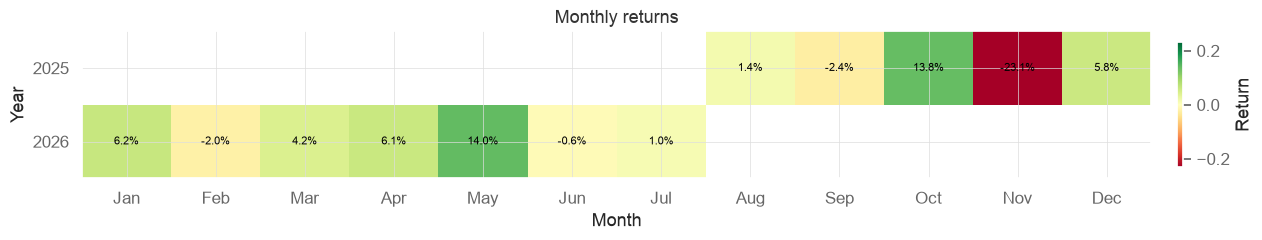

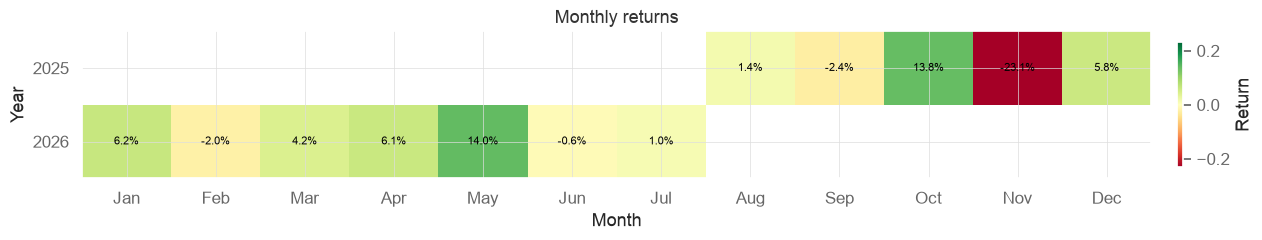

In [24]:
from tradeexecutor.visual.equity_curve import visualise_returns_over_time

monthly_returns_fig = visualise_returns_over_time(returns)
display(monthly_returns_fig)


# Positions at the end

- Inspect the live basket at the end of the backtest window.

In [25]:
stats = chart_renderer.render(positions_at_end)
display_head_and_tail(stats, head_rows=10, tail_rows=10)


,token,value,vault,protocol,link
position_id,,,,,
1,Lighter Li,9803.965094,Lighter Liquidity Provider (LLP),lighter,lighter-pool-281474976710654
11,Edge & Hed,9623.061458,Edge & Hedge (L/S Factors),lighter,lighter-pool-281474976688087
14,K Pool,9626.294667,K Pool,lighter,lighter-pool-281474976680237
15,BTC vs ALT,9156.719318,BTC vs ALTS and NEWS/DIPS,lighter,lighter-pool-281474976656586
24,Insertive,9490.320078,Insertive Capital (@onchainquant),lighter,lighter-pool-281474976643895
59,NYP- Not Y,8263.036107,NYP- Not YOUR pool,lighter,lighter-pool-281474976624925
71,Mid-HTF Tr,6774.494067,Mid-HTF Trading (@stablealt),lighter,lighter-pool-281474976623731
78,FLEXIBLE P,8427.327261,FLEXIBLE POOL,lighter,lighter-pool-281474976651007
79,PHP Tradin,3205.947396,PHP Trading Desk (BTC/USDC),lighter,lighter-pool-281474976593834


# Strategy thinking

- Sample the backtest cycle messages as head and tail slices instead of dumping the full table.

In [26]:
df = chart_renderer.render(last_messages)
display_head_and_tail(df, head_rows=5, tail_rows=5)


,0
2026-07-09,"Cycle: #343\nRebalanced: 👍\nOpen/about to open positions: 18\nMax position value change: 68.39 USD\nRebalance threshold: 50.00 USD\nTrades decided: 6\nPairs meeting inclusion criteria: 21\nPairs meeting TVL inclusion criteria: 25\nPositive trailing-Sharpe gate survivors: 18\nCandidate signals created: 18\nSelected survivor signals: 18\nWeight signal: positive_180d_sharpe_gate_then_age_ramp\nTrailing Sharpe lookback: 180 days\nAge ramp period: 0.875\nTotal equity: 120,595.37 USD\nCash: 2,441.37 USD\nRedeemable capital: 118,154.00 USD\nPending redemptions: 0.00 USD\nInvestable equity: 118,183.46 USD\nAccepted investable equity: 118,183.46 USD\nAllocated to signals: 118,183.46 USD\nDiscarded allocation because of lack of lit liquidity: 22,090.49 USD\nRebalance volume: 0.00 USD\nTop signal pair: Lighter Li-USDC\nTop signal value: 1.0\nTop signal weight: 1.0\nTop signal weight (normalised): 8.30 % (got 100.00 % of asked size)\nSignals with flag capped_by_pool_size: 8\nSignals with flag individual_trade_size_too_small: 7\n"
2026-07-08,"Cycle: #342\nRebalanced: 👍\nOpen/about to open positions: 18\nMax position value change: 8,738.91 USD\nRebalance threshold: 50.00 USD\nTrades decided: 12\nPairs meeting inclusion criteria: 21\nPairs meeting TVL inclusion criteria: 25\nPositive trailing-Sharpe gate survivors: 18\nCandidate signals created: 18\nSelected survivor signals: 18\nWeight signal: positive_180d_sharpe_gate_then_age_ramp\nTrailing Sharpe lookback: 180 days\nAge ramp period: 0.875\nTotal equity: 120,781.83 USD\nCash: 2,488.58 USD\nRedeemable capital: 118,293.25 USD\nPending redemptions: 0.00 USD\nInvestable equity: 118,366.19 USD\nAccepted investable equity: 118,366.19 USD\nAllocated to signals: 118,366.19 USD\nDiscarded allocation because of lack of lit liquidity: 22,426.32 USD\nRebalance volume: 0.00 USD\nTop signal pair: Lighter Li-USDC\nTop signal value: 1.0\nTop signal weight: 1.0\nTop signal weight (normalised): 8.33 % (got 100.00 % of asked size)\nSignals with flag capped_by_pool_size: 8\nSignals with flag individual_trade_size_too_small: 2\n"


# Alpha model diagnostics

- Inspect the alpha-model diagnostics table in compact form.

In [27]:
df = chart_renderer.render(alpha_model_diagnostics)
display_head_and_tail(df, head_rows=5, tail_rows=5)


Head (5 rows)


,Signal,Asked size,Accepted size,Value adjust USD,Weights (raw),Weights (norm/cap),Old weight,Flipping,TVL,Pending deposit USD,Pending redemption USD,Parked USD,Waiting deposit USD,Waiting redemption USD,Flags
Pair,,,,,,,,,,,,,,,
Candle Eff-USDC,0.150191,2647.311658,2069.092768,0.000000,0.150191,0.017507,0.017512,no flip,10345,-,-,-,-,-,capped_by_pool_size
Candle Eff-USDC,0.150191,3225.530547,3225.530547,21.110689,0.150191,0.027293,0.027121,no flip,30973,-,-,-,-,-,individual_trade_size_too_small
pmalt-USDC,0.193996,3419.444225,3419.444225,68.394994,0.193996,0.028933,0.028362,no flip,198482,-,-,-,-,-,
PHP Tradin-USDC,0.300381,4514.916918,3231.650138,25.702743,0.300381,0.027344,0.027134,no flip,16158,-,-,-,-,-,"capped_by_pool_size, individual_trade_size_too_small"
Mid-HTF Tr-USDC,0.459959,6862.521512,6774.494067,0.000000,0.459959,0.057322,0.057336,no flip,33872,-,-,-,-,-,capped_by_pool_size


Tail (5 rows)


,Signal,Asked size,Accepted size,Value adjust USD,Weights (raw),Weights (norm/cap),Old weight,Flipping,TVL,Pending deposit USD,Pending redemption USD,Parked USD,Waiting deposit USD,Waiting redemption USD,Flags
Pair,,,,,,,,,,,,,,,
Experiment-USDC,0.901144,9487.024319,8086.531570,0.000000,0.901144,0.068424,0.068441,no flip,40433,-,-,-,-,-,capped_by_pool_size
Edge & Hed-USDC,0.916789,9651.729603,9651.729603,28.668144,0.916789,0.081667,0.081445,no flip,2050702,-,-,-,-,-,individual_trade_size_too_small
Algorithmi-USDC,0.935563,9172.224310,2570.562074,0.000000,0.935563,0.021751,0.021756,no flip,12853,-,-,-,-,-,capped_by_pool_size
Guinea Poo-USDC,0.998142,9785.751020,9785.751020,42.497397,0.998142,0.082801,0.082462,no flip,98791,-,-,-,-,-,individual_trade_size_too_small
Lighter Li-USDC,1.000000,9803.965094,9803.965094,-67.654353,1.000000,0.082955,0.083549,no flip,75547517,-,-,-,-,-,


# Trading pair breakdown

- Review the vault-level realised contribution table with chain and address context.

In [28]:
df = chart_renderer.render(trading_pair_breakdown_with_chain)
display_head_and_tail(df, head_rows=10, tail_rows=10)


,Trading pair,Chain,Address,Positions,Trades,Total return %,Total PnL USD,Best,Worst,Avg,Median,Volume,Wins,Losses,Take profits,Stop losses,Trailing stop losses,Volatility
2,K Pool,Lighter,lighter-…,1,228,35.48%,"32,088.69",35.48%,35.48%,35.48%,35.48%,"203,363.62",1,0,0,0,0,0.00%
22,ETH 3x short,Lighter,lighter-…,6,22,21.80%,517.20,23.77%,-20.04%,3.63%,6.97%,"25,849.64",4,2,0,0,0,13.27%
23,BTC 3x short,Lighter,lighter-…,2,7,21.01%,11.71,40.41%,-19.40%,10.50%,10.50%,"12,107.60",1,1,0,0,0,29.90%
9,Guinea Pool,Lighter,lighter-…,3,210,9.72%,"3,165.09",26.81%,-14.72%,3.24%,-2.37%,"325,055.81",1,2,0,0,0,17.42%
1,Edge & Hedge (L/S Factors),Lighter,lighter-…,1,238,6.93%,"7,574.34",6.93%,6.93%,6.93%,6.93%,"216,539.47",1,0,0,0,0,0.00%
3,BTC vs ALTS and NEWS/DIPS,Lighter,lighter-…,1,209,5.16%,"3,748.33",5.16%,5.16%,5.16%,5.16%,"139,791.16",1,0,0,0,0,0.00%
8,PHP Trading Desk (BTC/USDC),Lighter,lighter-…,1,6,4.70%,143.97,4.70%,4.70%,4.70%,4.70%,"3,061.98",1,0,0,0,0,0.00%
0,Lighter Liquidity Provider (LLP),Lighter,lighter-…,1,274,3.95%,"2,927.61",3.95%,3.95%,3.95%,3.95%,"141,244.33",1,0,0,0,0,0.00%
4,Insertive Capital (@onchainquant),Lighter,lighter-…,1,203,3.88%,"3,775.88",3.88%,3.88%,3.88%,3.88%,"189,112.24",1,0,0,0,0,0.00%
13,pmalt,Lighter,lighter-…,4,14,3.41%,316.21,3.58%,-1.82%,0.85%,0.83%,"45,526.86",3,1,0,0,0,1.99%


# Trading metrics

- Keep the full trading metrics summary readable by slicing long output.

In [29]:
df = chart_renderer.render(trading_metrics)
display_head_and_tail(df, head_rows=10, tail_rows=10)


,0
Trading period length,342 days 0 hours
Trading start,None
Trading end,None
Return %,20.60%
Annualised return %,21.98%
Cash at start,"$100,000.00"
Value at end,"$120,595.37"
Time in market,0.00%
Time in market volatile,0.00%
Trade volume,"$2,458,226.53"


# Vault performance

- Inspect the vault-interest and position-level views for the executed backtest.

## Vault statistics

- Keep the compact vault interest summary as a full table.

In [30]:
df = chart_renderer.render(vault_statistics)
display_head_and_tail(df, head_rows=5, tail_rows=5)


,Metric,Value
0,Position count,99
1,Total interest earned,"20,595.37 USD"
2,Avg interest,-550.75%
3,Min interest,-7056.58%
4,Max interest,5522.96%
5,Avg credit position duration,"25 days, 0:00:00"
6,Total deposit flow in,"1,277,830.06 USD"
7,Min deposit,50.18 USD
8,Avg deposit,"1,369.59 USD"
9,Max deposit,"21,795.65 USD"


## Vault position list

- Show the most profitable and least profitable vault-position rows without dumping the full table.

In [31]:
df = chart_renderer.render(all_vault_positions_by_profit)
display_head_and_tail(df, head_rows=10, tail_rows=10)


,Vault,Opened,Closed,Profit % annualised,Profit USD,Price on open,Price on close,Price diff %,Price diff % ann.,Deposits,Redeems,Address
Id,,,,,,,,,,,,
60,ETH 3x short,2026-03-02,2026-03-03 00:00:00,51889213683396.64,98.56,0.00,0.00,7.67,0.02,1,1,lighter-pool-281474976710652
16,FLEXIBLE POOL,2025-12-01,2025-12-02 00:00:00,213247569102021722112.00,947.36,0.00,0.00,12.26,0.03,1,1,lighter-pool-281474976651007
80,Guinea Pool,2026-05-22,-,486.79,8280.88,0.00,0.00,24.79,3.33,22,25,lighter-pool-281474976694250
42,BTC 3x short,2026-01-30,2026-02-08 00:00:00,94894115.23,800.61,0.00,0.00,45.68,1.13,2,2,lighter-pool-281474976710650
32,DSC - L Strategy,2026-01-07,2026-01-08 00:00:00,7496.11,77.92,0.00,0.00,1.19,0.00,1,1,lighter-pool-281474976644517
11,Edge & Hedge (L/S Factors),2025-11-04,-,10.36,7574.34,0.00,0.00,26.92,18.29,110,128,lighter-pool-281474976688087
59,NYP- Not YOUR pool,2026-02-28,-,4.46,744.76,0.00,0.00,-13.24,-4.79,64,62,lighter-pool-281474976624925
51,ETH 3x short,2026-02-16,2026-02-26 00:00:00,240341.55,622.50,0.00,0.00,-11.44,-0.31,5,4,lighter-pool-281474976710652
98,Candle Effect v2,2026-07-07,-,13.83,5.06,0.00,0.00,0.11,0.00,1,1,lighter-pool-281474976543116
